# Amazon Sales Report Project using Python
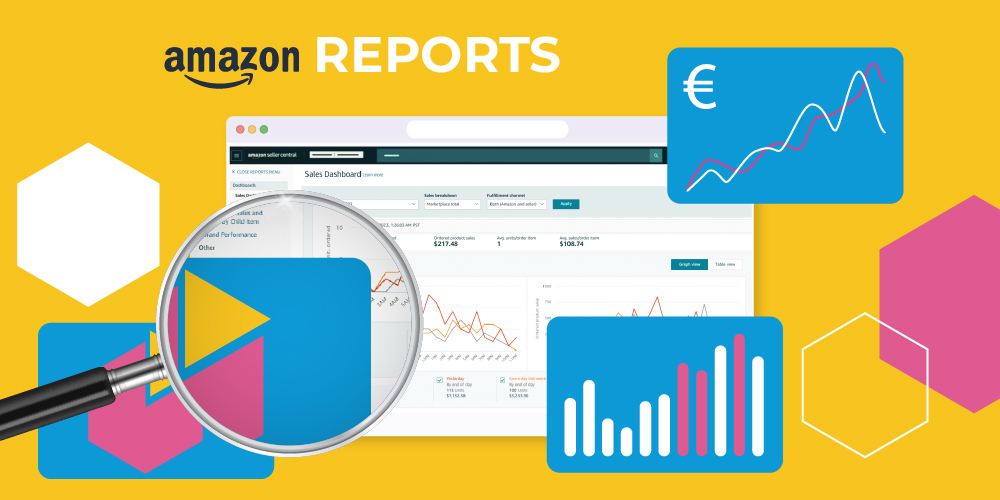

## 📝 Detailed Project Overview

### Project Object

The primary objective of this project is to conduct an in-depth exploratory data analysis (EDA) of Amazon sales data. This analysis aims to:

1.  **Identify Sales Trends:** Uncover patterns related to sales volume, revenue, and product categories over different periods (daily, monthly).
2.  **Evaluate Fulfillment Performance:** Compare the efficiency and revenue contribution of `Amazon-fulfilled` versus `Merchant-fulfilled` orders.
3.  **Geographical Insights:** Pinpoint high-performing states and regions in terms of sales and quantity sold.
4.  **Product Performance Analysis:** Determine top-selling product categories and sizes.
5.  **Data-Driven Recommendations:** Provide actionable conclusions and strategic recommendations to optimize sales, marketing efforts, and logistical operations.

### Data Explanation

The dataset used for this analysis comprises Amazon sales records, covering various transactional details. Key features include:

*   **Order ID:** Unique identifier for each order.
*   **Date:** The date of the order (`datetime` type).
*   **Status:** Current status of the order (e.g., `SHIPPED`, `CANCELLED`).
*   **Fulfilment:** Indicates whether the order was `AMAZON-FULFILLED` or `MERCHANT-FULFILLED`.
*   **Sales Channel:** The platform through which the sale was made (`AMAZON.IN` in this dataset).
*   **ship-service-level:** The shipping service level (e.g., `STANDARD`, `EXPEDITED`).
*   **Category & Size:** Product details (e.g., `T-SHIRT`, `SHIRT` for Category; `S`, `M`, `L` for Size).
*   **Courier Status:** Current status with the courier (e.g., `SHIPPED`, `ON THE WAY`).
*   **Qty:** Quantity of items sold in the order.
*   **currency & Amount:** Currency (`INR`) and total amount of the order.
*   **ship-city, ship-state, ship-postal-code, ship-country:** Geographical information for delivery.
*   **B2B:** Boolean indicating if it's a Business-to-Business order.
*   **Day_Name, Month_Name, Year:** Derived features from the `Date` column for temporal analysis.

### Company Explanation

Amazon.com, Inc. is an American multinational technology company focusing on e-commerce, cloud computing, online advertising, digital streaming, and artificial intelligence. This analysis specifically pertains to sales data from **Amazon.in**, its Indian e-commerce arm. Understanding these sales trends is crucial for Amazon to maintain its competitive edge, optimize its extensive supply chain, enhance customer satisfaction, and drive continued growth in the highly dynamic Indian market. The insights gained can directly inform decisions on inventory management, marketing strategies, fulfillment logistics, and regional expansion.

In [1]:
# Draft: FRD: Functional Requirement Draft
# BRD: Business Requirement Draft
# Data: Complete info

# Step 1: Import Required Modules

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import datetime as dt
import warnings
warnings.filterwarnings('ignore')
print('All Modules Loaded Successfully!!')

All Modules Loaded Successfully!!


# Step 2: Load Dataset

In [3]:
url = 'https://docs.google.com/spreadsheets/d/1kR-gFZwc58nWsP48yt5y4ibjWhWNj_uk15W1v7jDk3Y/export?format=csv&gid=785549489'
df = pd.read_csv(url)
print('Done')

Done


In [4]:
df

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by,New,PendingS
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship,NaN,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship,NaN,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,NaN,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship,NaN,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128971,128970,406-6001380-7673107,05-31-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,...,INR,517.00,HYDERABAD,TELANGANA,500013.0,IN,False,NaN,NaN,NaN
128972,128971,402-9551604-7544318,05-31-22,Shipped,Amazon,Amazon.in,Expedited,T-shirt,M,Shipped,...,INR,999.00,GURUGRAM,HARYANA,122004.0,IN,False,NaN,NaN,NaN
128973,128972,407-9547469-3152358,05-31-22,Shipped,Amazon,Amazon.in,Expedited,Blazzer,XXL,Shipped,...,INR,690.00,HYDERABAD,TELANGANA,500049.0,IN,False,NaN,NaN,NaN
128974,128973,402-6184140-0545956,05-31-22,Shipped,Amazon,Amazon.in,Expedited,T-shirt,XS,Shipped,...,INR,1199.00,Halol,Gujarat,389350.0,IN,False,NaN,NaN,NaN


# Step 3: EDA: Exploratory data Analysis

In [5]:
# 3.1
r,c = df.shape
print(f'''This dataset contains
rows: {r}
columns: {c}''')

This dataset contains
rows: 128976
columns: 21


In [6]:
# 3.2
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128976 entries, 0 to 128975
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128976 non-null  int64  
 1   Order ID            128976 non-null  object 
 2   Date                128976 non-null  object 
 3   Status              128976 non-null  object 
 4   Fulfilment          128976 non-null  object 
 5   Sales Channel       128976 non-null  object 
 6   ship-service-level  128976 non-null  object 
 7   Category            128976 non-null  object 
 8   Size                128976 non-null  object 
 9   Courier Status      128976 non-null  object 
 10  Qty                 128976 non-null  int64  
 11  currency            121176 non-null  object 
 12  Amount              121176 non-null  float64
 13  ship-city           128941 non-null  object 
 14  ship-state          128941 non-null  object 
 15  ship-postal-code    128941 non-nul

In [7]:
# 3.3: set max_limit for rows and cols
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns',c)

In [8]:
# 3.4
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by,New,PendingS
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship,NaN,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship,NaN,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,NaN,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship,NaN,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,NaN,NaN,NaN


In [9]:
# 3.5
df.tail()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by,New,PendingS
128971,128970,406-6001380-7673107,05-31-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,1,INR,517.0,HYDERABAD,TELANGANA,500013.0,IN,False,NaN,NaN,NaN
128972,128971,402-9551604-7544318,05-31-22,Shipped,Amazon,Amazon.in,Expedited,T-shirt,M,Shipped,1,INR,999.0,GURUGRAM,HARYANA,122004.0,IN,False,NaN,NaN,NaN
128973,128972,407-9547469-3152358,05-31-22,Shipped,Amazon,Amazon.in,Expedited,Blazzer,XXL,Shipped,1,INR,690.0,HYDERABAD,TELANGANA,500049.0,IN,False,NaN,NaN,NaN
128974,128973,402-6184140-0545956,05-31-22,Shipped,Amazon,Amazon.in,Expedited,T-shirt,XS,Shipped,1,INR,1199.0,Halol,Gujarat,389350.0,IN,False,NaN,NaN,NaN
128975,128974,408-7436540-8728312,05-31-22,Shipped,Amazon,Amazon.in,Expedited,T-shirt,S,Shipped,1,INR,696.0,Raipur,CHHATTISGARH,492014.0,IN,False,NaN,NaN,NaN


In [10]:
# 3.6
df.sample(2)

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by,New,PendingS
14761,14760,407-5894094-6121924,04-21-22,Cancelled,Merchant,Amazon.in,Standard,Shirt,S,On the Way,0,INR,540.95,BHILAI,CHHATTISGARH,491107.0,IN,False,Easy Ship,NaN,NaN
122199,122198,408-4843133-7321130,06-05-2022,Shipped,Amazon,Amazon.in,Expedited,T-shirt,XXL,Shipped,1,INR,666.00,GURUGRAM,HARYANA,122004.0,IN,False,NaN,NaN,NaN


In [11]:
# 3.7
all_columns = df.columns
print(all_columns)

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Category', 'Size', 'Courier Status', 'Qty',
       'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code',
       'ship-country', 'B2B', 'fulfilled-by', 'New', 'PendingS'],
      dtype='object')


In [12]:
# 3.8: Duplicate data check
df.duplicated('Order ID').sum()

np.int64(8747)

In [13]:
# 3.9: Check duplocate data %
duplicate_per = (df.duplicated('Order ID').sum()/r)*100
print(f'{round(duplicate_per,2)}% of data is duplicate')

6.78% of data is duplicate


In [14]:
actual_data_per = 100-duplicate_per
print(f'{round(actual_data_per,2)}% of data is Actual')


93.22% of data is Actual


In [15]:
# 3.10 : drop duplicate data
new_df = df.drop_duplicates('Order ID')

In [16]:
# 3.11
new_df.shape

(120229, 21)

In [17]:
all_columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Category', 'Size', 'Courier Status', 'Qty',
       'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code',
       'ship-country', 'B2B', 'fulfilled-by', 'New', 'PendingS'],
      dtype='object')

In [18]:
# 3.12: Drop unwanted cols
new_df.drop(['index','New','PendingS'], axis = 1, inplace=True)
print('Done')

Done


In [19]:
new_df.shape

(120229, 18)

In [20]:
# 3.13 Check Missing data in %
new_df.isna().mean().sort_values(ascending = False)*100

fulfilled-by          69.788487
currency               6.150762
Amount                 6.150762
ship-country           0.023289
ship-postal-code       0.023289
ship-city              0.023289
ship-state             0.023289
Order ID               0.000000
Date                   0.000000
Status                 0.000000
Qty                    0.000000
Courier Status         0.000000
Size                   0.000000
Category               0.000000
ship-service-level     0.000000
Sales Channel          0.000000
Fulfilment             0.000000
B2B                    0.000000
dtype: float64

In [21]:
new_df['fulfilled-by'].value_counts()

fulfilled-by
Easy Ship    36323
Name: count, dtype: int64

In [22]:
new_df[new_df['fulfilled-by'].isna()]['Fulfilment'].value_counts()

Fulfilment
Amazon    83906
Name: count, dtype: int64

In [23]:
new_df[~new_df['fulfilled-by'].isna()]['Fulfilment'].value_counts()


Fulfilment
Merchant    36323
Name: count, dtype: int64

In [24]:
# In case of NaN:
# 1: Ignore Nan : wrong analysis
# 2: Fill na : domain: knowledge
# 3: drop na : data loss

# new_df['fulfilled-by'].fillna('other')
# new_df['currency'].fillna('Unknown')
# new_df['Amount'].fillna(0)

In [25]:
new_df[new_df['currency'].isna()]['Status'].value_counts()

Status
Cancelled                       7220
Shipped                          161
Shipping                           8
Shipped - Delivered to Buyer       4
Shipped - Returned to Seller       1
Pending                            1
Name: count, dtype: int64

In [26]:
new_df[new_df['currency'].isna()]

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by
8,407-5443024-5233168,04-30-22,Cancelled,Amazon,Amazon.in,Expedited,T-shirt,3XL,Cancelled,0,NaN,NaN,HYDERABAD,TELANGANA,500008.0,IN,False,NaN
29,404-5933402-8801952,04-30-22,Cancelled,Merchant,Amazon.in,Standard,Shirt,3XL,On the Way,0,NaN,NaN,GUWAHATI,ASSAM,781003.0,IN,False,Easy Ship
65,171-4137548-0481151,04-30-22,Cancelled,Amazon,Amazon.in,Expedited,Shirt,XXL,Cancelled,0,NaN,NaN,Dahod,Gujarat,389151.0,IN,False,NaN
84,403-9950518-0349133,04-30-22,Cancelled,Amazon,Amazon.in,Expedited,Shirt,M,Cancelled,0,NaN,NaN,HYDERABAD,TELANGANA,500072.0,IN,False,NaN
95,405-9112089-3379536,04-30-22,Cancelled,Amazon,Amazon.in,Expedited,Shirt,L,Cancelled,0,NaN,NaN,PUNE,MAHARASHTRA,411046.0,IN,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128903,406-4220789-1106743,05-31-22,Cancelled,Amazon,Amazon.in,Expedited,Blazzer,L,Cancelled,0,NaN,NaN,ANANTAPUR,ANDHRA PRADESH,515001.0,IN,False,NaN
128904,406-3923120-4345139,05-31-22,Cancelled,Amazon,Amazon.in,Expedited,Shirt,M,Cancelled,0,NaN,NaN,ANANTAPUR,ANDHRA PRADESH,515001.0,IN,False,NaN
128908,403-6757403-6097100,05-31-22,Cancelled,Amazon,Amazon.in,Expedited,T-shirt,3XL,Cancelled,0,NaN,NaN,GREATER NOIDA,UTTAR PRADESH,201306.0,IN,False,NaN
128959,408-9513596-4393945,05-31-22,Cancelled,Amazon,Amazon.in,Expedited,T-shirt,L,Cancelled,0,NaN,NaN,Bengaluru,KARNATAKA,560037.0,IN,False,NaN


In [27]:
new_df[~new_df['currency'].isna()]


,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,NaN
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128971,406-6001380-7673107,05-31-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,1,INR,517.00,HYDERABAD,TELANGANA,500013.0,IN,False,NaN
128972,402-9551604-7544318,05-31-22,Shipped,Amazon,Amazon.in,Expedited,T-shirt,M,Shipped,1,INR,999.00,GURUGRAM,HARYANA,122004.0,IN,False,NaN
128973,407-9547469-3152358,05-31-22,Shipped,Amazon,Amazon.in,Expedited,Blazzer,XXL,Shipped,1,INR,690.00,HYDERABAD,TELANGANA,500049.0,IN,False,NaN
128974,402-6184140-0545956,05-31-22,Shipped,Amazon,Amazon.in,Expedited,T-shirt,XS,Shipped,1,INR,1199.00,Halol,Gujarat,389350.0,IN,False,NaN


In [28]:
new_df[new_df['ship-city'].isna()].head(5)

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by
1872,404-0566904-4825137,04-29-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,L,Shipped,1,INR,493.0,NaN,NaN,NaN,NaN,False,NaN
8753,406-4003386-8768363,04-25-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,M,Shipped,1,INR,432.0,NaN,NaN,NaN,NaN,False,NaN
11216,402-0107720-7057168,04-23-22,Shipped,Amazon,Amazon.in,Expedited,T-shirt,S,Shipped,1,INR,654.0,NaN,NaN,NaN,NaN,False,NaN
13253,407-4532637-8415521,04-22-22,Cancelled,Merchant,Amazon.in,Standard,Shirt,S,On the Way,0,INR,380.0,NaN,NaN,NaN,NaN,False,Easy Ship
15689,404-9229894-8608305,04-21-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,M,Shipped,1,INR,442.0,NaN,NaN,NaN,NaN,False,NaN


In [29]:
new_df[~new_df['ship-city'].isna()].head(5)


,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,NaN
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,NaN


In [30]:
new_df['ship-country'].value_counts()

ship-country
IN    120201
Name: count, dtype: int64

In [31]:
new_df['ship-city'].isna().sum()

np.int64(28)

In [32]:
(28/new_df.shape[0])*100

0.023288890367548595

In [33]:
# since the missing % is very less close to 0.02 % we can drop this

In [34]:
final_df =  new_df.copy()

In [35]:
final_df['fulfilled-by'] = final_df['fulfilled-by'].fillna('other')
final_df['currency'] = final_df['currency'].fillna('Unknown')
final_df['Amount'] = final_df['Amount'].fillna(0)

In [36]:
final_df.dropna(inplace = True)

In [37]:
# 3.14: check missing % for final_df
final_df.isna().sum()

Order ID              0
Date                  0
Status                0
Fulfilment            0
Sales Channel         0
ship-service-level    0
Category              0
Size                  0
Courier Status        0
Qty                   0
currency              0
Amount                0
ship-city             0
ship-state            0
ship-postal-code      0
ship-country          0
B2B                   0
fulfilled-by          0
dtype: int64

In [38]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120201 entries, 0 to 128975
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Order ID            120201 non-null  object 
 1   Date                120201 non-null  object 
 2   Status              120201 non-null  object 
 3   Fulfilment          120201 non-null  object 
 4   Sales Channel       120201 non-null  object 
 5   ship-service-level  120201 non-null  object 
 6   Category            120201 non-null  object 
 7   Size                120201 non-null  object 
 8   Courier Status      120201 non-null  object 
 9   Qty                 120201 non-null  int64  
 10  currency            120201 non-null  object 
 11  Amount              120201 non-null  float64
 12  ship-city           120201 non-null  object 
 13  ship-state          120201 non-null  object 
 14  ship-postal-code    120201 non-null  float64
 15  ship-country        120201 non-null  ob

In [39]:
final_df['Date'] = pd.to_datetime(final_df['Date'])

In [40]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120201 entries, 0 to 128975
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Order ID            120201 non-null  object        
 1   Date                120201 non-null  datetime64[ns]
 2   Status              120201 non-null  object        
 3   Fulfilment          120201 non-null  object        
 4   Sales Channel       120201 non-null  object        
 5   ship-service-level  120201 non-null  object        
 6   Category            120201 non-null  object        
 7   Size                120201 non-null  object        
 8   Courier Status      120201 non-null  object        
 9   Qty                 120201 non-null  int64         
 10  currency            120201 non-null  object        
 11  Amount              120201 non-null  float64       
 12  ship-city           120201 non-null  object        
 13  ship-state          120201 non-nul

In [41]:
final_df.sample(5)

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by
86039,403-6192533-1825126,2022-05-03,Shipped,Amazon,Amazon.in,Expedited,T-shirt,S,Shipped,1,INR,597.0,Jamshedpur,JHARKHAND,831015.0,IN,False,other
71929,408-8196538-3179555,2022-05-13,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,1,INR,574.0,KOCHI,KERALA,682005.0,IN,False,other
109469,171-2684565-2181944,2022-06-14,Shipped,Amazon,Amazon.in,Expedited,T-shirt,M,Shipped,1,INR,850.0,CHENNAI,TAMIL NADU,600045.0,IN,False,other
189,408-3874942-9917143,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,T-shirt,XL,Shipped,1,INR,1126.0,SAMBHAL,UTTAR PRADESH,244302.0,IN,False,other
114931,405-3876119-9173937,2022-06-10,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,1,INR,376.0,VADODARA,Gujarat,391350.0,IN,False,other


In [42]:
textual_columns = final_df.select_dtypes('object').columns

In [43]:
numerical_columns = final_df.select_dtypes('number').columns

In [44]:
date_columns = final_df.select_dtypes('datetime').columns

In [45]:
bool_columns = final_df.select_dtypes('bool').columns

In [46]:
final_df['Category'].apply(lambda row: row.strip().upper())

0          T-SHIRT
1            SHIRT
2            SHIRT
3          BLAZZER
4         TROUSERS
            ...   
128971       SHIRT
128972     T-SHIRT
128973     BLAZZER
128974     T-SHIRT
128975     T-SHIRT
Name: Category, Length: 120201, dtype: object

In [47]:
final_df[textual_columns] = final_df[textual_columns].apply(lambda row: row.str.strip().str.upper())

In [48]:
final_df

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by
0,405-8078784-5731545,2022-04-30,CANCELLED,MERCHANT,AMAZON.IN,STANDARD,T-SHIRT,S,ON THE WAY,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,EASY SHIP
1,171-9198151-1101146,2022-04-30,SHIPPED - DELIVERED TO BUYER,MERCHANT,AMAZON.IN,STANDARD,SHIRT,3XL,SHIPPED,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,EASY SHIP
2,404-0687676-7273146,2022-04-30,SHIPPED,AMAZON,AMAZON.IN,EXPEDITED,SHIRT,XL,SHIPPED,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,OTHER
3,403-9615377-8133951,2022-04-30,CANCELLED,MERCHANT,AMAZON.IN,STANDARD,BLAZZER,L,ON THE WAY,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,EASY SHIP
4,407-1069790-7240320,2022-04-30,SHIPPED,AMAZON,AMAZON.IN,EXPEDITED,TROUSERS,3XL,SHIPPED,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,OTHER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128971,406-6001380-7673107,2022-05-31,SHIPPED,AMAZON,AMAZON.IN,EXPEDITED,SHIRT,XL,SHIPPED,1,INR,517.00,HYDERABAD,TELANGANA,500013.0,IN,False,OTHER
128972,402-9551604-7544318,2022-05-31,SHIPPED,AMAZON,AMAZON.IN,EXPEDITED,T-SHIRT,M,SHIPPED,1,INR,999.00,GURUGRAM,HARYANA,122004.0,IN,False,OTHER
128973,407-9547469-3152358,2022-05-31,SHIPPED,AMAZON,AMAZON.IN,EXPEDITED,BLAZZER,XXL,SHIPPED,1,INR,690.00,HYDERABAD,TELANGANA,500049.0,IN,False,OTHER
128974,402-6184140-0545956,2022-05-31,SHIPPED,AMAZON,AMAZON.IN,EXPEDITED,T-SHIRT,XS,SHIPPED,1,INR,1199.00,HALOL,GUJARAT,389350.0,IN,False,OTHER


In [49]:
# 3.14: Add new: year, Month, Day

final_df['Day_Name'] = final_df['Date'].dt.day_name()
final_df['Month_Name'] = final_df['Date'].dt.month_name()
final_df['Year'] = final_df['Date'].dt.year


In [50]:
final_df

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by,Day_Name,Month_Name,Year
0,405-8078784-5731545,2022-04-30,CANCELLED,MERCHANT,AMAZON.IN,STANDARD,T-SHIRT,S,ON THE WAY,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,EASY SHIP,Saturday,April,2022
1,171-9198151-1101146,2022-04-30,SHIPPED - DELIVERED TO BUYER,MERCHANT,AMAZON.IN,STANDARD,SHIRT,3XL,SHIPPED,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,EASY SHIP,Saturday,April,2022
2,404-0687676-7273146,2022-04-30,SHIPPED,AMAZON,AMAZON.IN,EXPEDITED,SHIRT,XL,SHIPPED,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,OTHER,Saturday,April,2022
3,403-9615377-8133951,2022-04-30,CANCELLED,MERCHANT,AMAZON.IN,STANDARD,BLAZZER,L,ON THE WAY,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,EASY SHIP,Saturday,April,2022
4,407-1069790-7240320,2022-04-30,SHIPPED,AMAZON,AMAZON.IN,EXPEDITED,TROUSERS,3XL,SHIPPED,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,OTHER,Saturday,April,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128971,406-6001380-7673107,2022-05-31,SHIPPED,AMAZON,AMAZON.IN,EXPEDITED,SHIRT,XL,SHIPPED,1,INR,517.00,HYDERABAD,TELANGANA,500013.0,IN,False,OTHER,Tuesday,May,2022
128972,402-9551604-7544318,2022-05-31,SHIPPED,AMAZON,AMAZON.IN,EXPEDITED,T-SHIRT,M,SHIPPED,1,INR,999.00,GURUGRAM,HARYANA,122004.0,IN,False,OTHER,Tuesday,May,2022
128973,407-9547469-3152358,2022-05-31,SHIPPED,AMAZON,AMAZON.IN,EXPEDITED,BLAZZER,XXL,SHIPPED,1,INR,690.00,HYDERABAD,TELANGANA,500049.0,IN,False,OTHER,Tuesday,May,2022
128974,402-6184140-0545956,2022-05-31,SHIPPED,AMAZON,AMAZON.IN,EXPEDITED,T-SHIRT,XS,SHIPPED,1,INR,1199.00,HALOL,GUJARAT,389350.0,IN,False,OTHER,Tuesday,May,2022


In [51]:
final_df.shape

(120201, 21)

# Step 4: Data Stats:

In [52]:
#Step 4.1
final_df.describe()

,Date,Qty,Amount,ship-postal-code,Year
count,120201,120201.000000,120201.000000,120201.000000,120201.0
mean,2022-05-12 11:52:18.173559808,0.903595,609.880208,463571.890067,2022.0
min,2022-03-31 00:00:00,0.000000,0.000000,110001.000000,2022.0
25%,2022-04-20 00:00:00,1.000000,416.000000,382007.000000,2022.0
50%,2022-05-10 00:00:00,1.000000,589.000000,500032.000000,2022.0
75%,2022-06-04 00:00:00,1.000000,771.000000,600024.000000,2022.0
max,2022-06-29 00:00:00,15.000000,5495.000000,989898.000000,2022.0
std,NaN,0.313013,314.204252,192179.470165,0.0


In [53]:
final_df.describe(include='object')

,Order ID,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,currency,ship-city,ship-state,ship-country,fulfilled-by,Day_Name,Month_Name
count,120201,120201,120201,120201,120201,120201,120201,120201,120201,120201,120201,120201,120201,120201,120201
unique,120201,13,2,2,2,9,11,4,2,7291,47,1,2,7,4
top,408-7436540-8728312,SHIPPED,AMAZON,AMAZON.IN,EXPEDITED,T-SHIRT,M,SHIPPED,INR,BENGALURU,MAHARASHTRA,IN,OTHER,Sunday,April
freq,1,72730,83890,120077,82811,47135,21060,102027,112808,11080,20756,120201,83890,18205,45698


# Step 5: Different Analysis
  - **Univariate Analysis**
  - **Bivariate Analysis**
  - **Multivariate Analysis**

In [54]:
# Step 5.1 : Univariate Analysis: Single Column Analysis
# Numerical Col, textual Col,

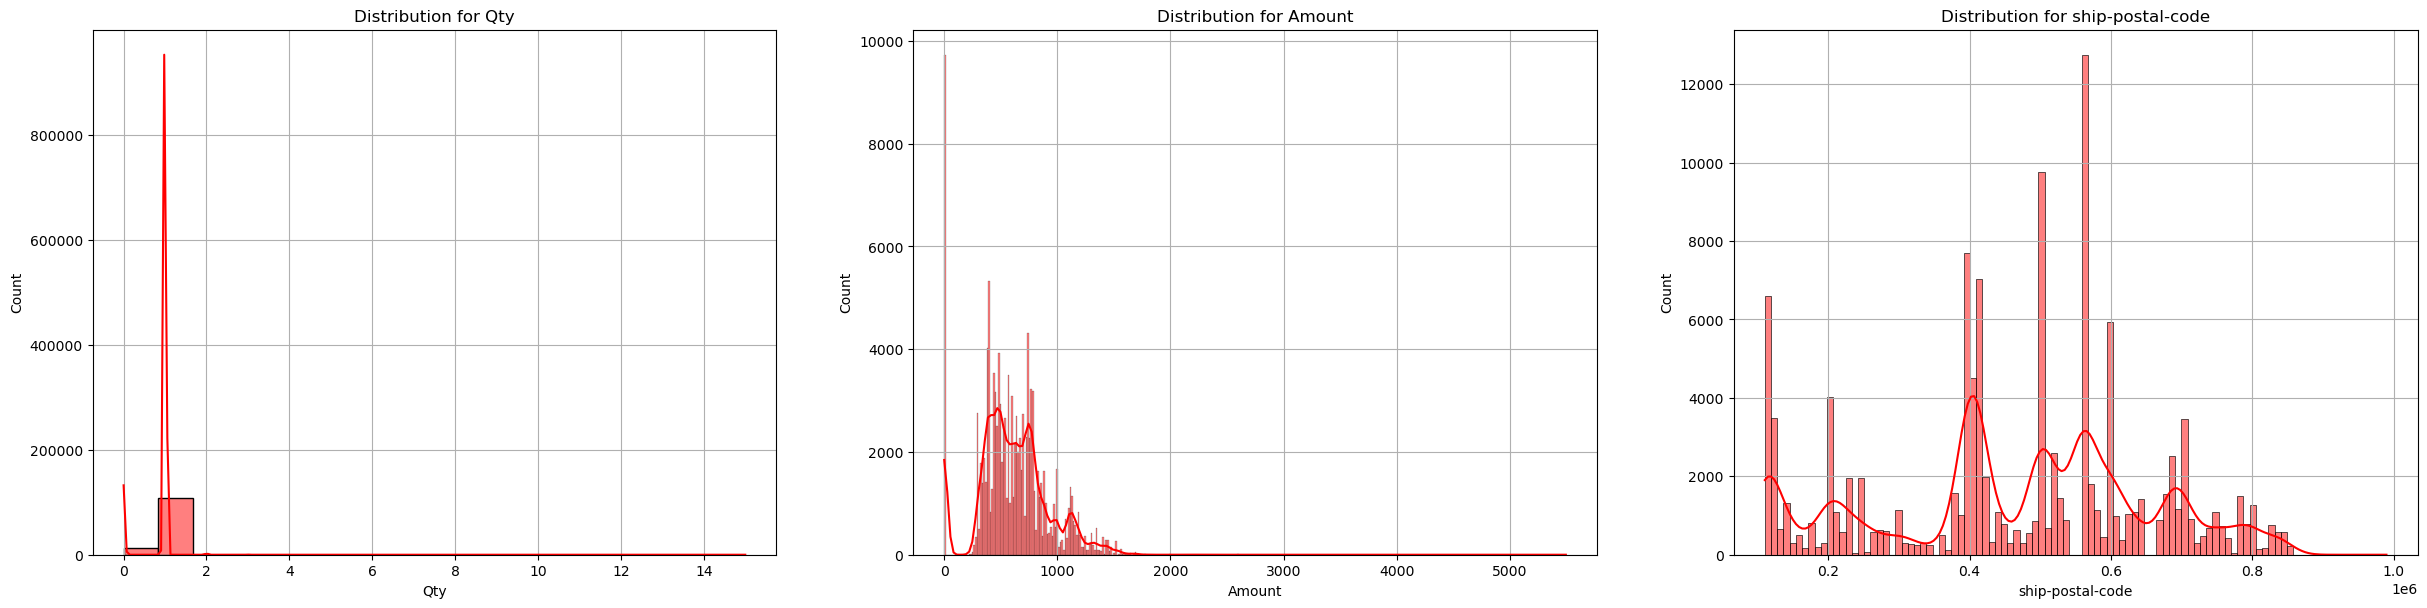

In [55]:
import random
plt.figure(figsize=(30,15))

for index, i in enumerate(final_df[numerical_columns]):
  # print(i)
  plt.subplot(2,3,index+1)
  plt.title(f'Distribution for {i}')
  colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']
  sns.histplot(final_df[i], kde = True, color = random.choice(colors))
  plt.grid()
plt.show()

In [56]:
# textual Col
for index,col in enumerate(final_df[textual_columns]):
  # print(col)
  print('******************************\n\n')
  print(f'Analysis by {col}')
  ans = final_df[col].value_counts().head(15)
  display(ans)

******************************


Analysis by Order ID


Order ID
408-7436540-8728312    1
405-8078784-5731545    1
171-9198151-1101146    1
404-0687676-7273146    1
403-9615377-8133951    1
407-1069790-7240320    1
404-1490984-4578765    1
408-5748499-6859555    1
406-7807733-3785945    1
406-3440574-1454703    1
403-8460761-3295511    1
408-3874942-4863549    1
408-4323946-0210734    1
403-9660720-7207506    1
403-6231612-3153120    1
Name: count, dtype: int64

******************************


Analysis by Status


Status
SHIPPED                          72730
SHIPPED - DELIVERED TO BUYER     26514
CANCELLED                        17160
SHIPPED - RETURNED TO SELLER      1847
SHIPPED - PICKED UP                918
PENDING                            584
PENDING - WAITING FOR PICK UP      262
SHIPPED - RETURNING TO SELLER      130
SHIPPED - OUT FOR DELIVERY          32
SHIPPED - REJECTED BY BUYER         11
SHIPPING                             8
SHIPPED - LOST IN TRANSIT            4
SHIPPED - DAMAGED                    1
Name: count, dtype: int64

******************************


Analysis by Fulfilment


...

ship-state
MAHARASHTRA       20756
KARNATAKA         16162
TAMIL NADU        10507
TELANGANA         10394
UTTAR PRADESH     10057
DELHI              6520
KERALA             6097
WEST BENGAL        5645
ANDHRA PRADESH     4970
GUJARAT            4161
HARYANA            4134
RAJASTHAN          2503
MADHYA PRADESH     2375
ODISHA             2020
BIHAR              2014
Name: count, dtype: int64

******************************


Analysis by ship-country


ship-country
IN    120201
Name: count, dtype: int64

******************************


Analysis by fulfilled-by


fulfilled-by
OTHER        83890
EASY SHIP    36311
Name: count, dtype: int64

In [57]:
len(textual_columns)
c = ["deep","muted","bright","pastel","dark","colorblind","cool","hot","spring","summer",
       "viridis", "plasma", "inferno", "magma", "cividis", "coolwarm", "rainbow", "cubehelix", "flare", "crest"]
print(c)

['deep', 'muted', 'bright', 'pastel', 'dark', 'colorblind', 'cool', 'hot', 'spring', 'summer', 'viridis', 'plasma', 'inferno', 'magma', 'cividis', 'coolwarm', 'rainbow', 'cubehelix', 'flare', 'crest']


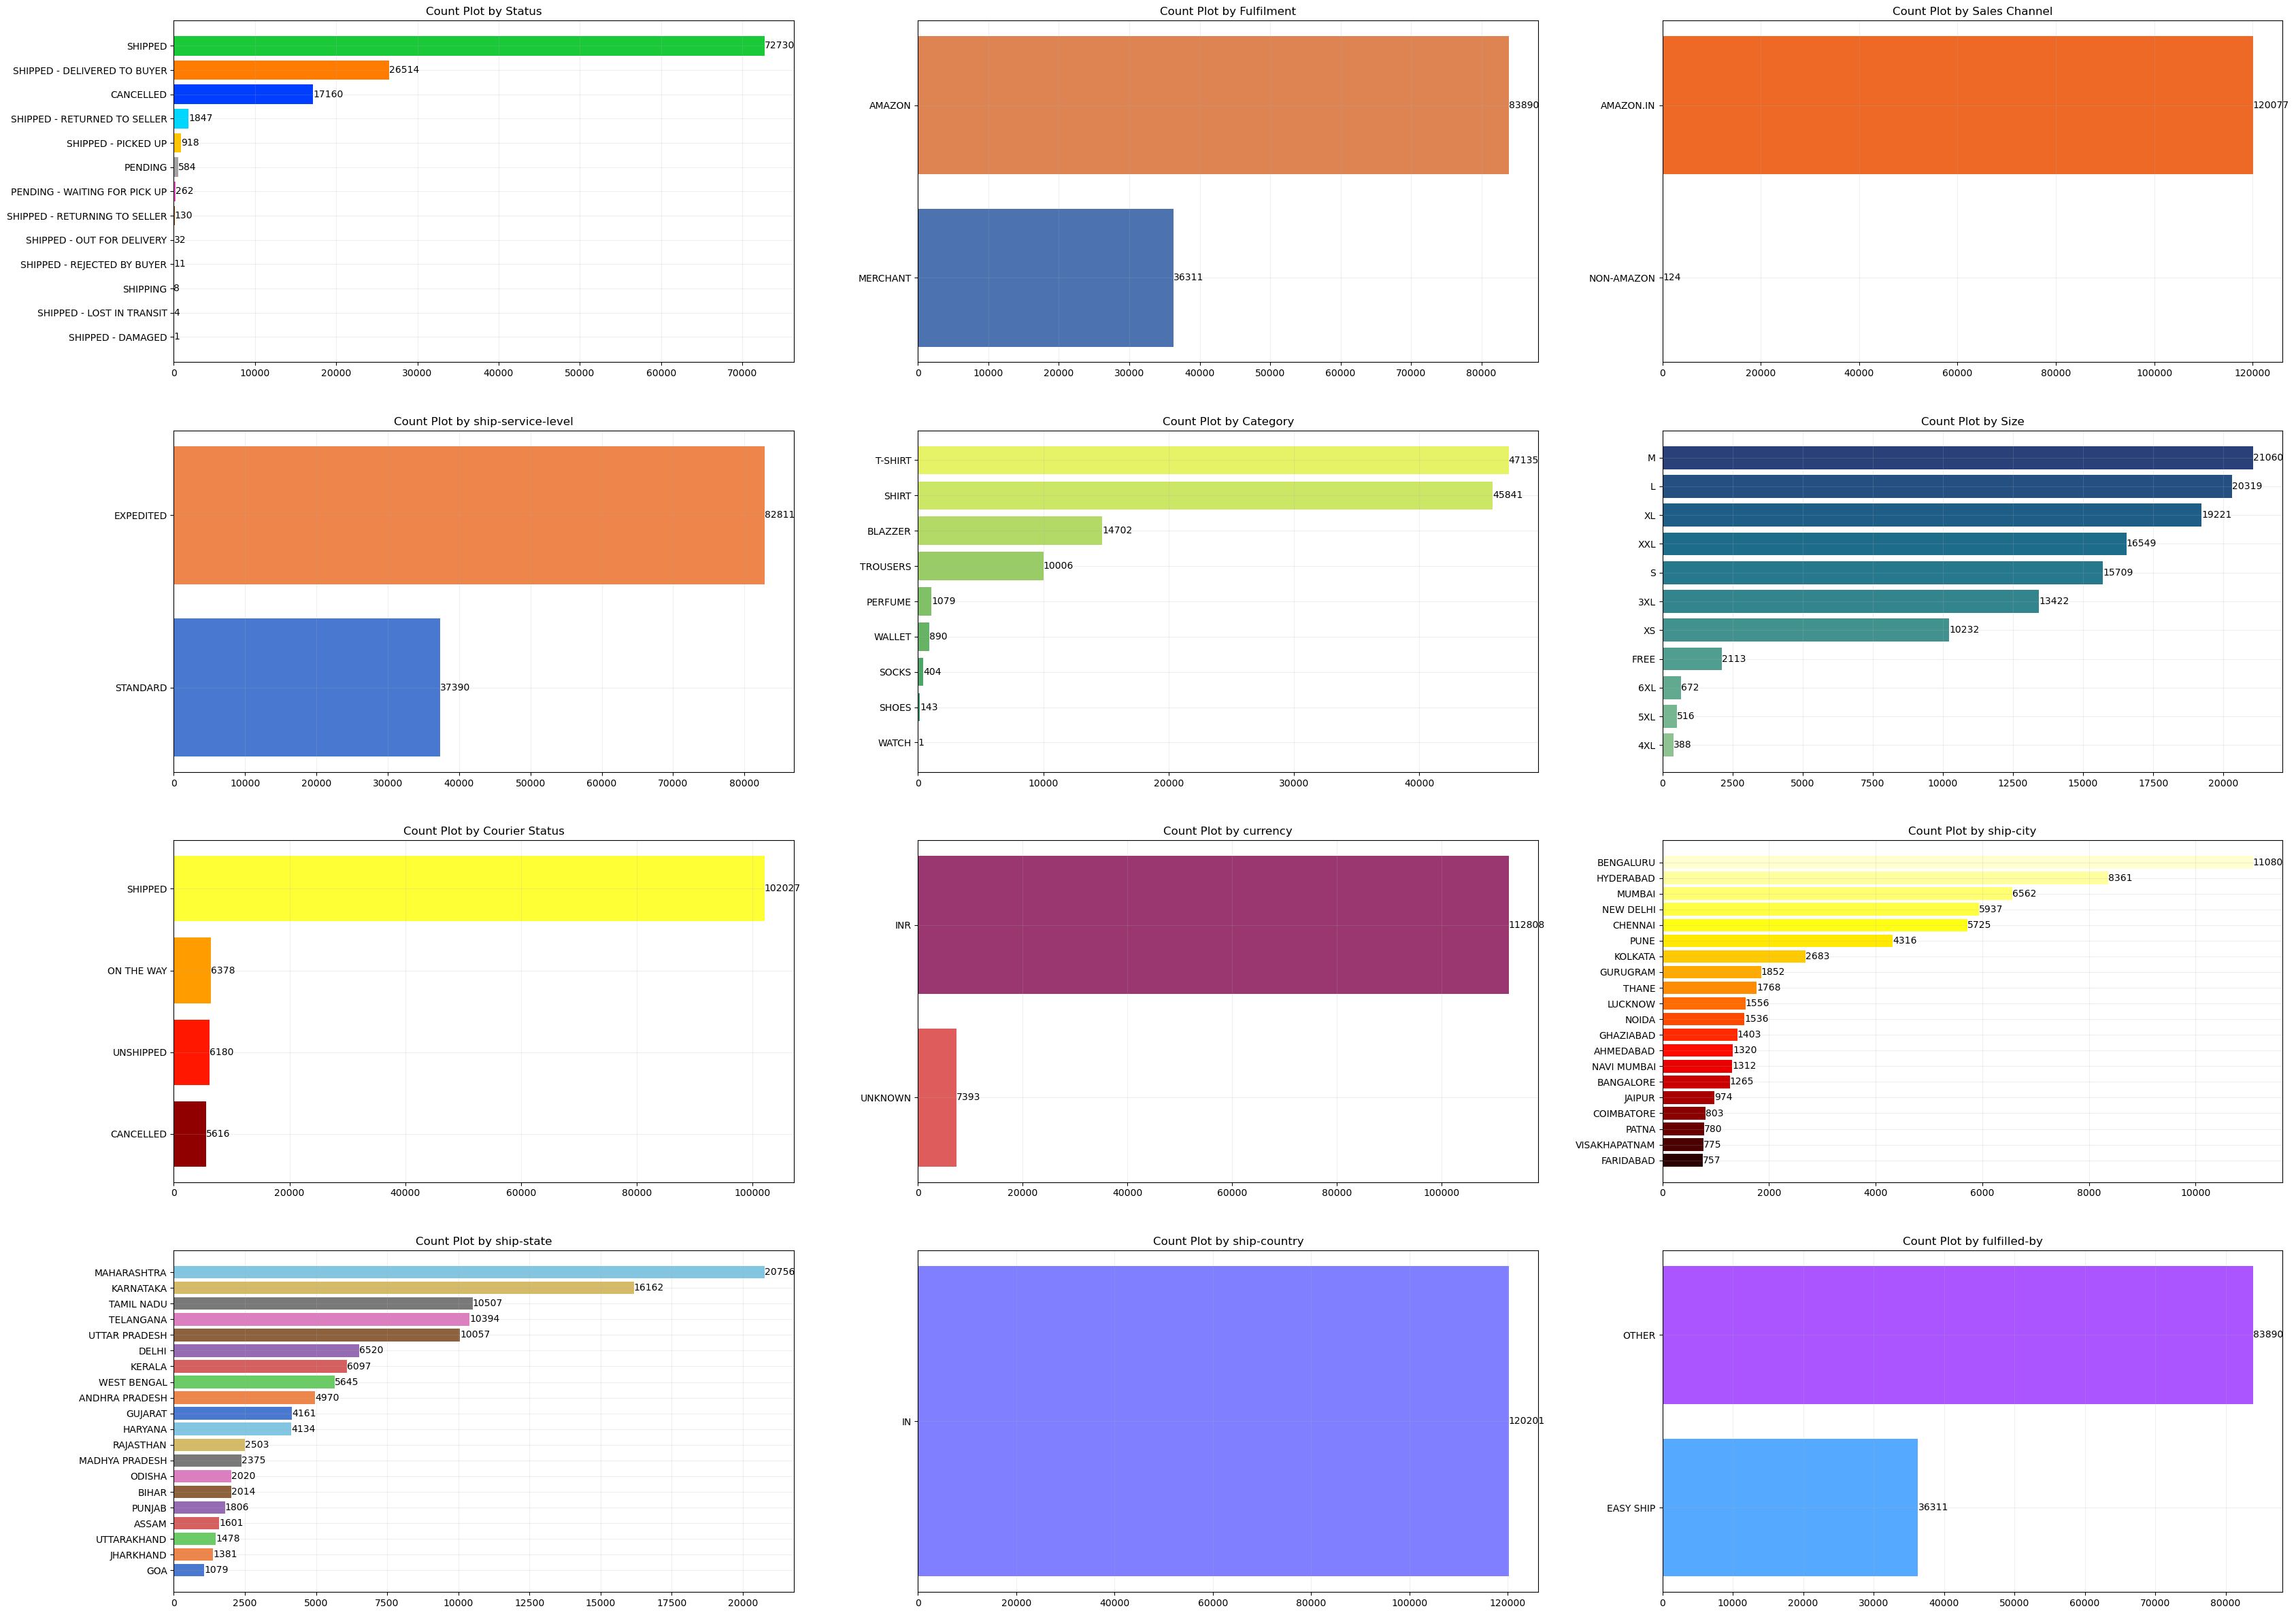

In [58]:
plt.figure(figsize=(40,30))
for index,col in enumerate(final_df[textual_columns[1:]]):
  # print(i)
  plt.subplot(4,3,index+1)
  plt.title(f'Count Plot by {col}')
  temp_data = final_df[col].value_counts().sort_values(ascending = False).head(20)
  # display(temp_data)
  x = temp_data.index[::-1]
  y = temp_data.values[::-1]
  # print(x,y)
  ax = plt.barh(x,y, color = sns.color_palette(random.choice(c), len(x)))
  plt.bar_label(ax)
  plt.grid(alpha = 0.2)
plt.show()

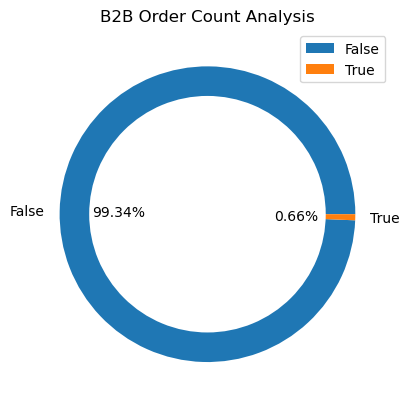

In [59]:
# B2B
label = final_df['B2B'].value_counts().index
values = final_df['B2B'].value_counts().values
plt.title('B2B Order Count Analysis')
plt.pie(values, labels = label, autopct = '%.2f%%')
plt.pie((1,), radius = 0.8, colors='w')
plt.legend()
plt.show()

In [60]:
import calendar
all_months_name = list(calendar.month_name)[1:]

temp_month_count = pd.Categorical(final_df['Month_Name'], categories=all_months_name, ordered=True).value_counts()

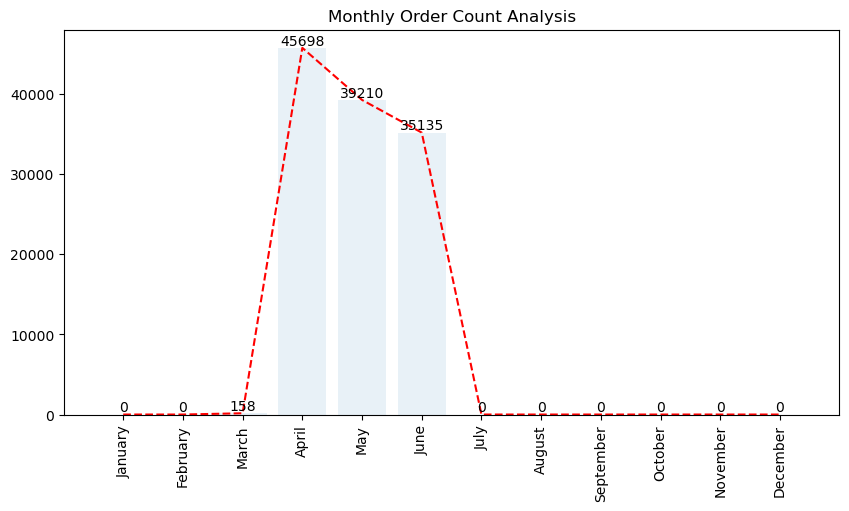

In [61]:
plt.figure(figsize=(10,5))
plt.plot(all_months_name, temp_month_count.values, color = 'r', linestyle = '--')
ax = plt.bar(all_months_name, temp_month_count.values, alpha = 0.1)
plt.bar_label(ax)
plt.xticks(rotation = 90)
plt.title('Monthly Order Count Analysis')
plt.show()


In [62]:
all_days_name = list(calendar.day_name)
day_temp_count = pd.Categorical(final_df['Day_Name'], categories=all_days_name, ordered=True).value_counts()

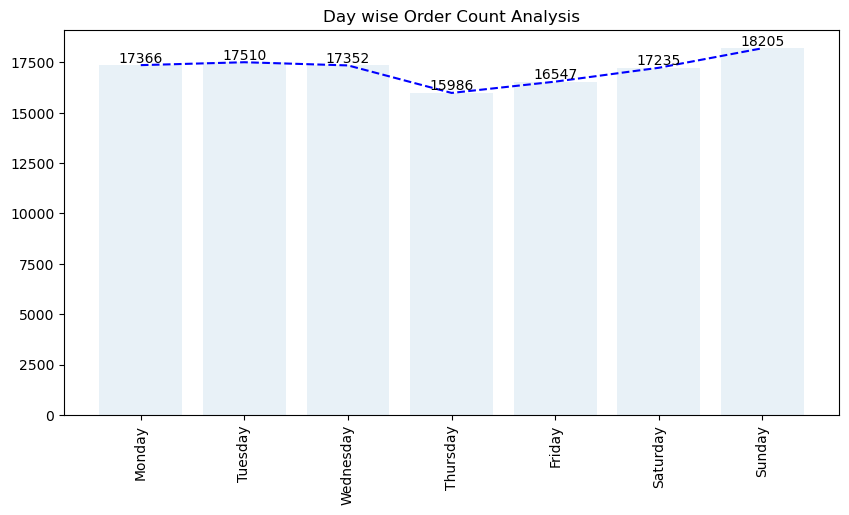

In [63]:
plt.figure(figsize=(10,5))
plt.plot(all_days_name, day_temp_count .values, color = 'b', linestyle = '--')
ax = plt.bar(all_days_name, day_temp_count .values, alpha = 0.1)
plt.bar_label(ax)
plt.xticks(rotation = 90)
plt.title('Day wise Order Count Analysis')
plt.show()


In [64]:
# Data Analysis
# Company: Problems: Solution:Skill ?:
# Problems:

In [65]:
# Bivariate Analysis

In [66]:
final_df.columns

Index(['Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Category', 'Size', 'Courier Status', 'Qty',
       'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code',
       'ship-country', 'B2B', 'fulfilled-by', 'Day_Name', 'Month_Name',
       'Year'],
      dtype='object')

In [67]:
list_1 = list(final_df.columns[1:])
removed_cols = ['currency', 'Qty', 'Amount','ship-postal-code','ship-country','Date']
for i in removed_cols:
  list_1.remove(i)

analysis_1 = 'Qty'
analysis_2 = 'Amount'

print(list_1, len(list_1))
print(analysis_1, analysis_2)

['Status', 'Fulfilment', 'Sales Channel', 'ship-service-level', 'Category', 'Size', 'Courier Status', 'ship-city', 'ship-state', 'B2B', 'fulfilled-by', 'Day_Name', 'Month_Name', 'Year'] 14
Qty Amount


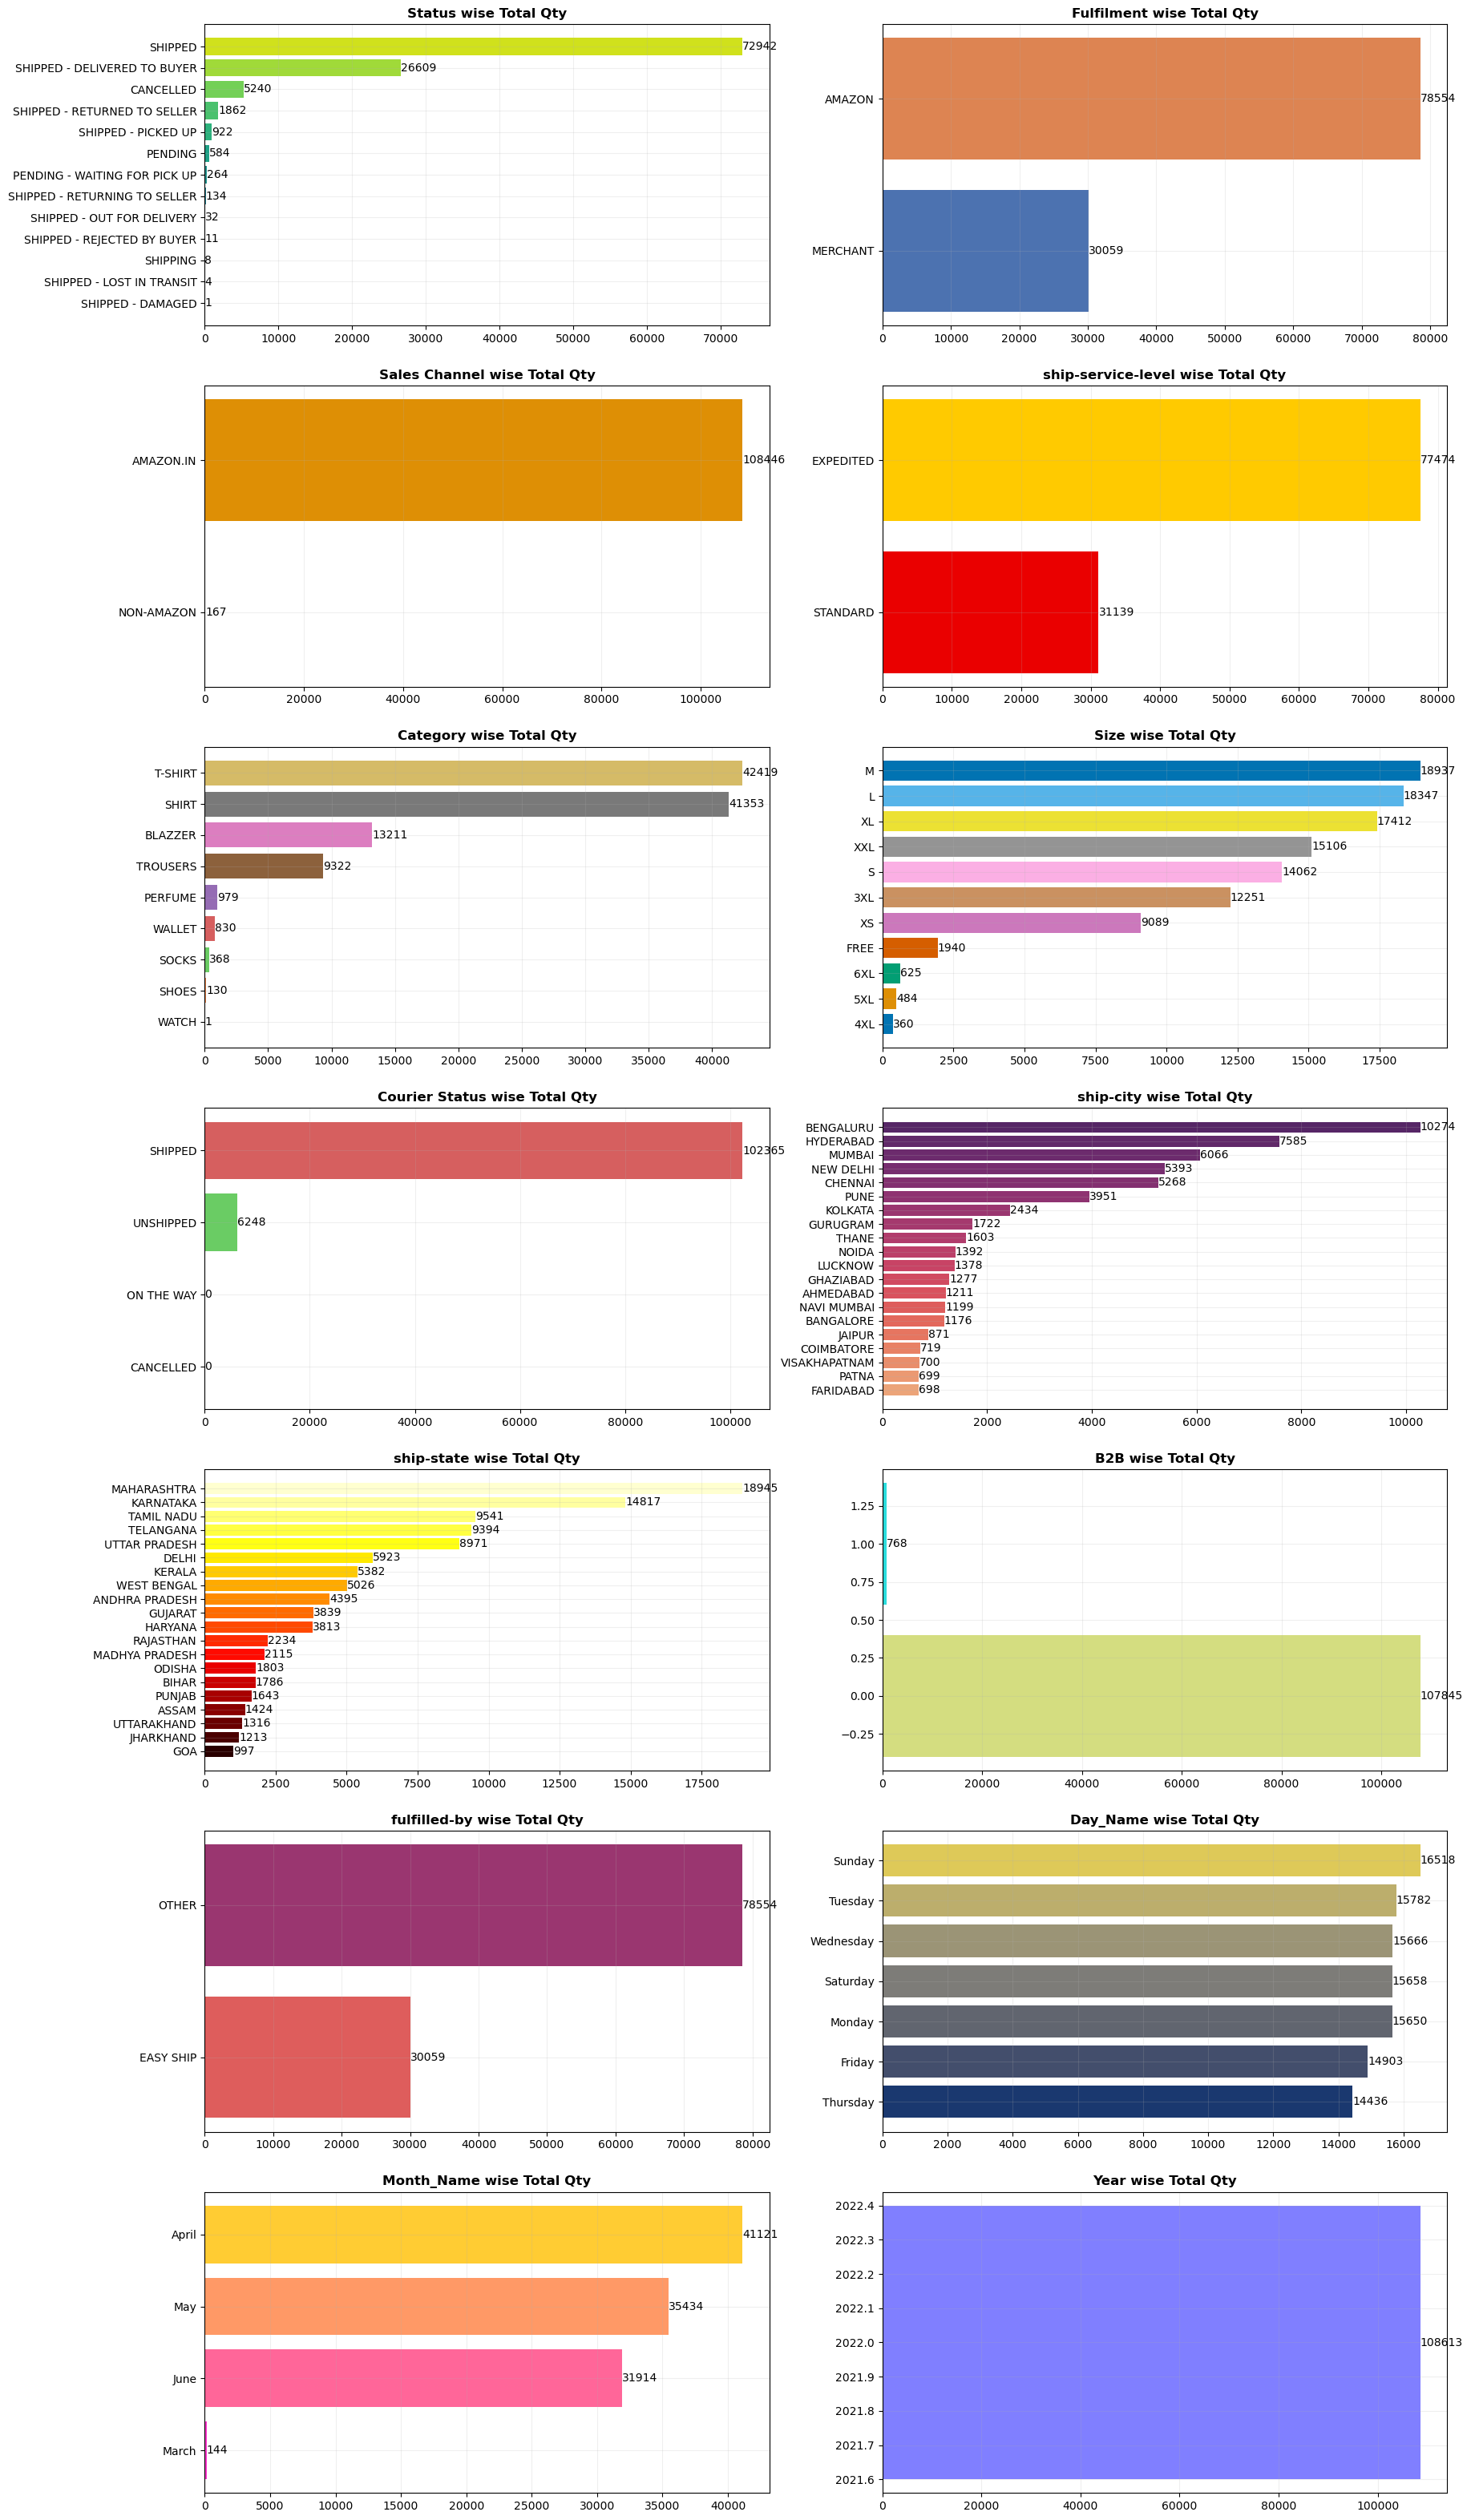

In [68]:
plt.figure(figsize=(20,40))
for index, i in enumerate(list_1):
  plt.subplot(7,2, index +1)
  plt.title(f'{i} wise Total {analysis_1}', fontweight = 'bold')
  temp_df = final_df.groupby(i)[analysis_1].sum().sort_values(ascending = False).head(20)
  x = temp_df.index[::-1]
  y = temp_df.values[::-1]
  ax = plt.barh(x,y, color = sns.color_palette(random.choice(c), len(x)))
  plt.bar_label(ax)
  plt.grid(alpha = 0.2)

plt.show()


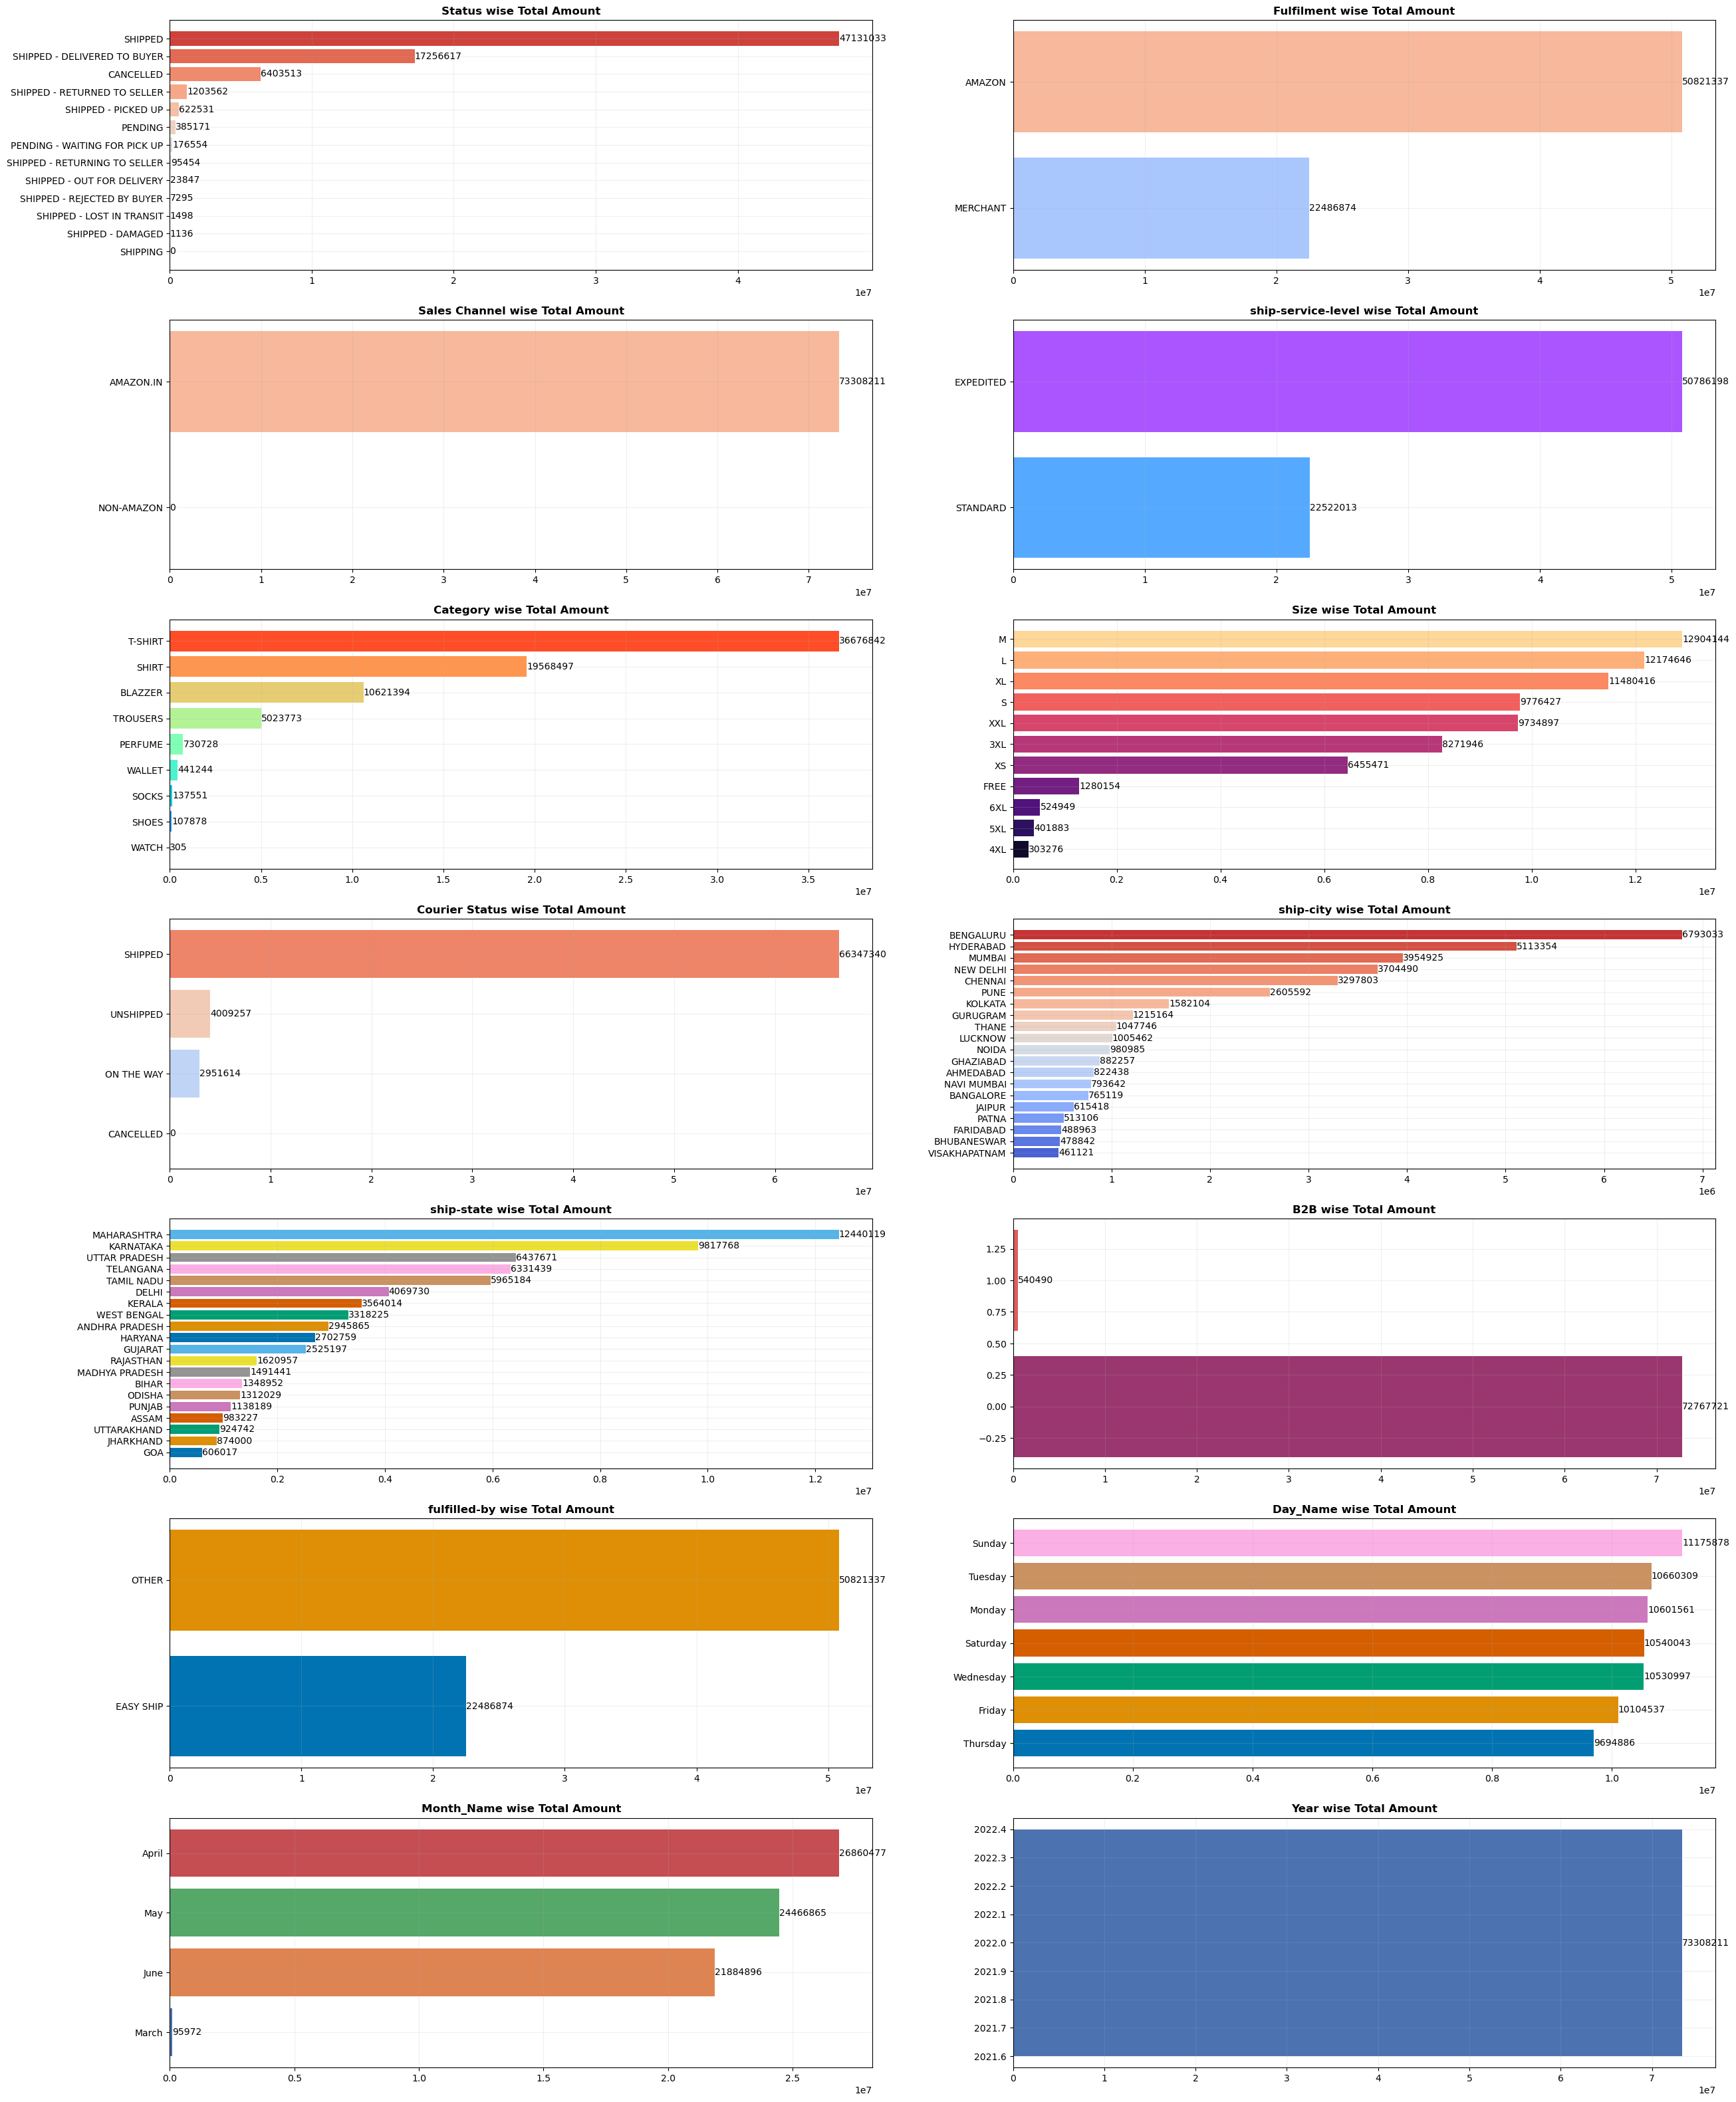

In [69]:
plt.figure(figsize=(30,40))
for index, i in enumerate(list_1):
  plt.subplot(7,2, index +1)
  plt.title(f'{i} wise Total {analysis_2}', fontweight = 'bold')
  temp_df = final_df.groupby(i)[analysis_2].sum().sort_values(ascending = False).head(20)
  x = temp_df.index[::-1]
  y = temp_df.values[::-1]
  ax = plt.barh(x,y, color = sns.color_palette(random.choice(c), len(x)))
  plt.bar_label(ax, fmt='%.0f')
  plt.grid(alpha = 0.2)

plt.show()


In [70]:
grouped_df = final_df.groupby('Month_Name')

In [71]:
final_df['Month_Name'].unique()

array(['April', 'March', 'May', 'June'], dtype=object)

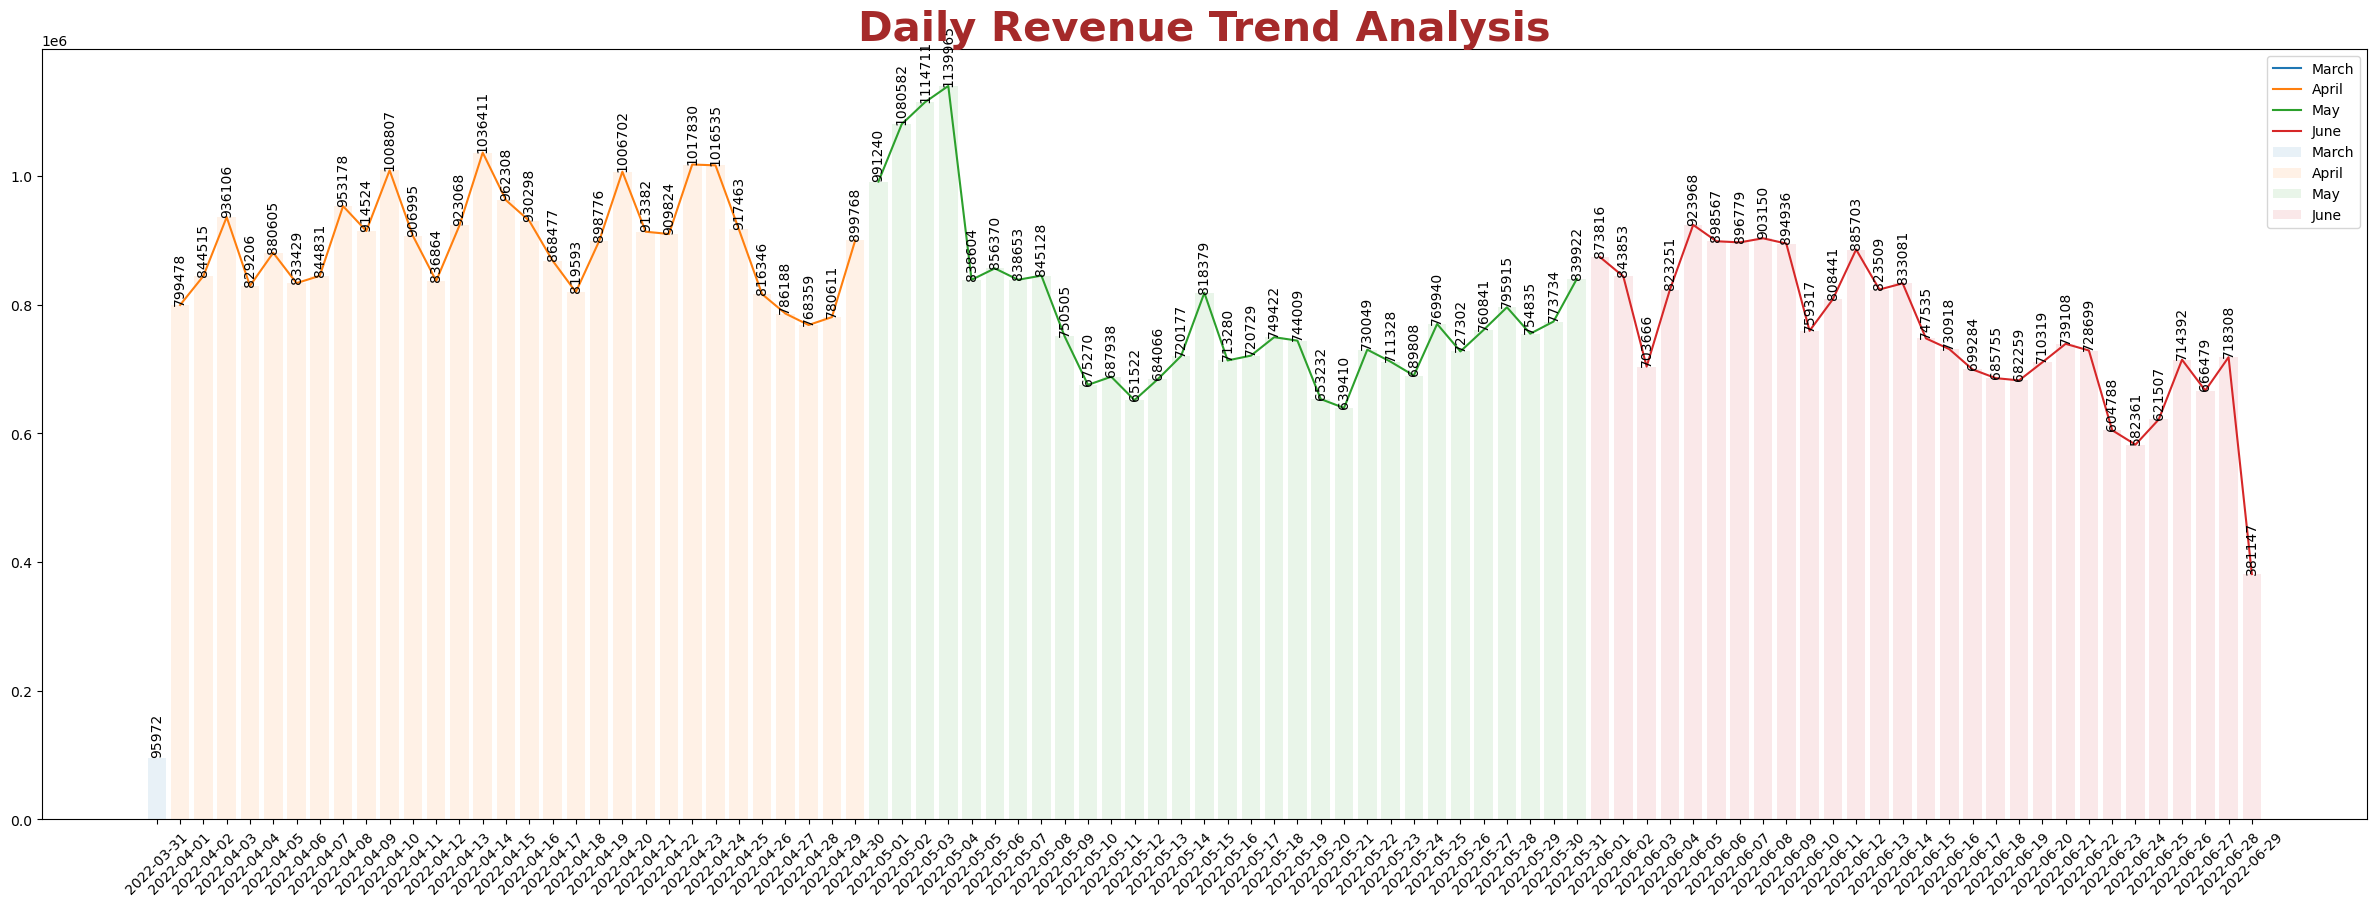

In [72]:
plt.figure(figsize=(30,10))
plt.title('Daily Revenue Trend Analysis', fontsize = 30, fontweight = 'bold', color = 'brown')
x_axis_data = []
for i in all_months_name:
  try:
    temp_df = grouped_df.get_group(i)[['Date', 'Amount']]
  except:
    pass
  else:
    temp_df = temp_df.groupby('Date')['Amount'].sum()
    x_axis_data.extend(temp_df.index.date.tolist())
    plt.plot(temp_df.index, temp_df.values, label = i)
    ax = plt.bar(temp_df.index, temp_df.values, label = i, alpha = 0.1)
    plt.bar_label(ax, fmt = '%.0f', rotation = 90)
plt.xticks(x_axis_data, rotation = 45)
plt.legend()
plt.show()

# Multivariate Analysis
  - Corr
  - Pair plot
  - Pivot table
  - Multiple Group by

In [73]:
final_df.columns

Index(['Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Category', 'Size', 'Courier Status', 'Qty',
       'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code',
       'ship-country', 'B2B', 'fulfilled-by', 'Day_Name', 'Month_Name',
       'Year'],
      dtype='object')

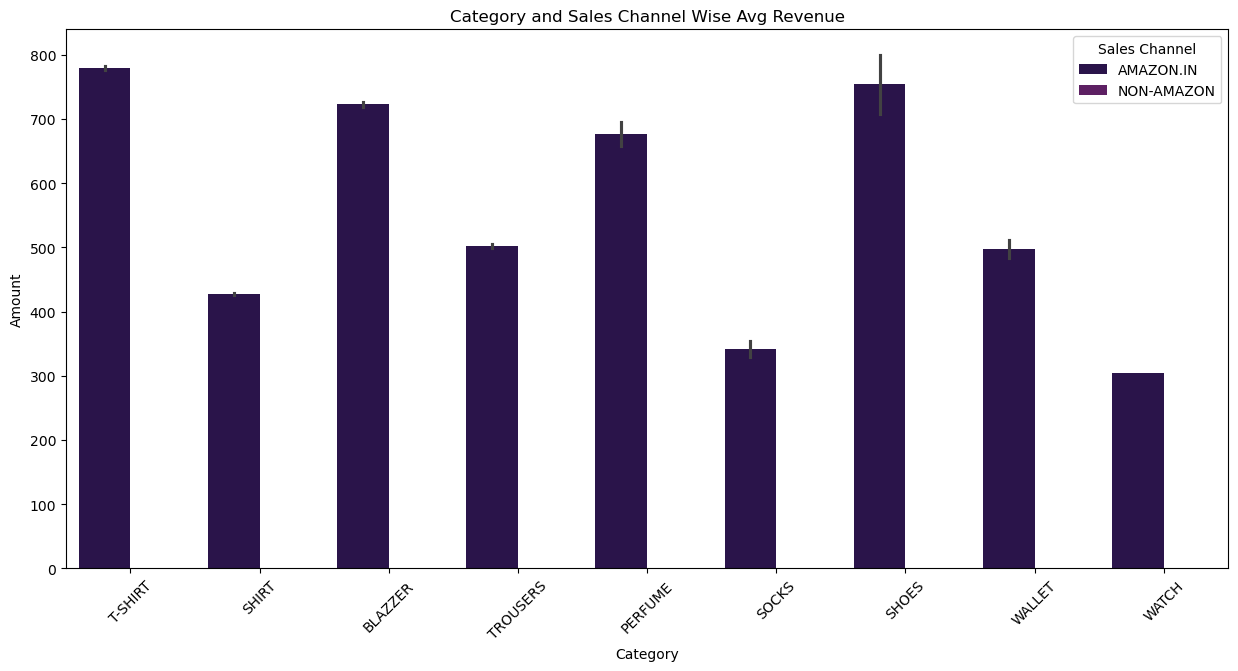

In [74]:
# Category and Sales Channel Wise Revenue
plt.figure(figsize=(15,7))
plt.title('Category and Sales Channel Wise Avg Revenue')
sns.barplot(x = 'Category', y = 'Amount', hue = 'Sales Channel', data = final_df, palette=sns.color_palette(random.choice(c)))
plt.xticks(rotation = 45)
plt.show()

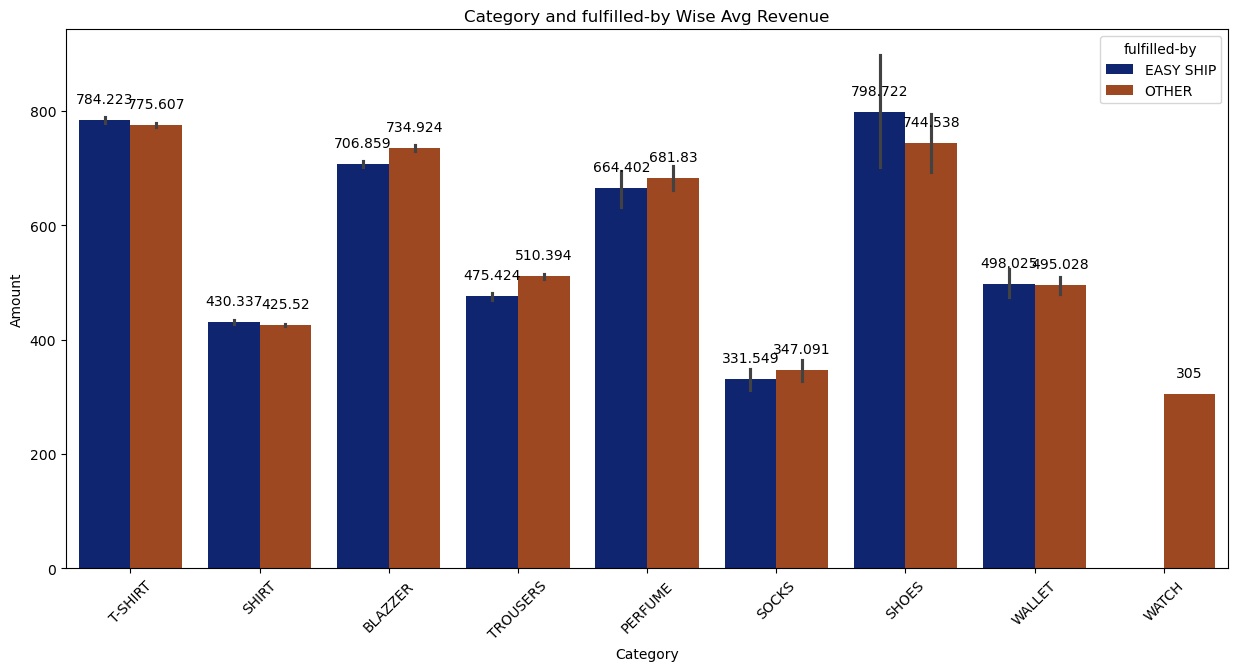

In [75]:
# Category and Sales fulfilled-by Revenue
plt.figure(figsize=(15,7))
plt.title('Category and fulfilled-by Wise Avg Revenue')
ax = sns.barplot(x = 'Category', y = 'Amount', hue = 'fulfilled-by', data = final_df, palette=sns.color_palette(random.choice(c)))
for i in ax.containers:
  ax.bar_label(i,  padding=10)
plt.xticks(rotation = 45)
plt.show()

In [76]:
final_df.columns

Index(['Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Category', 'Size', 'Courier Status', 'Qty',
       'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code',
       'ship-country', 'B2B', 'fulfilled-by', 'Day_Name', 'Month_Name',
       'Year'],
      dtype='object')

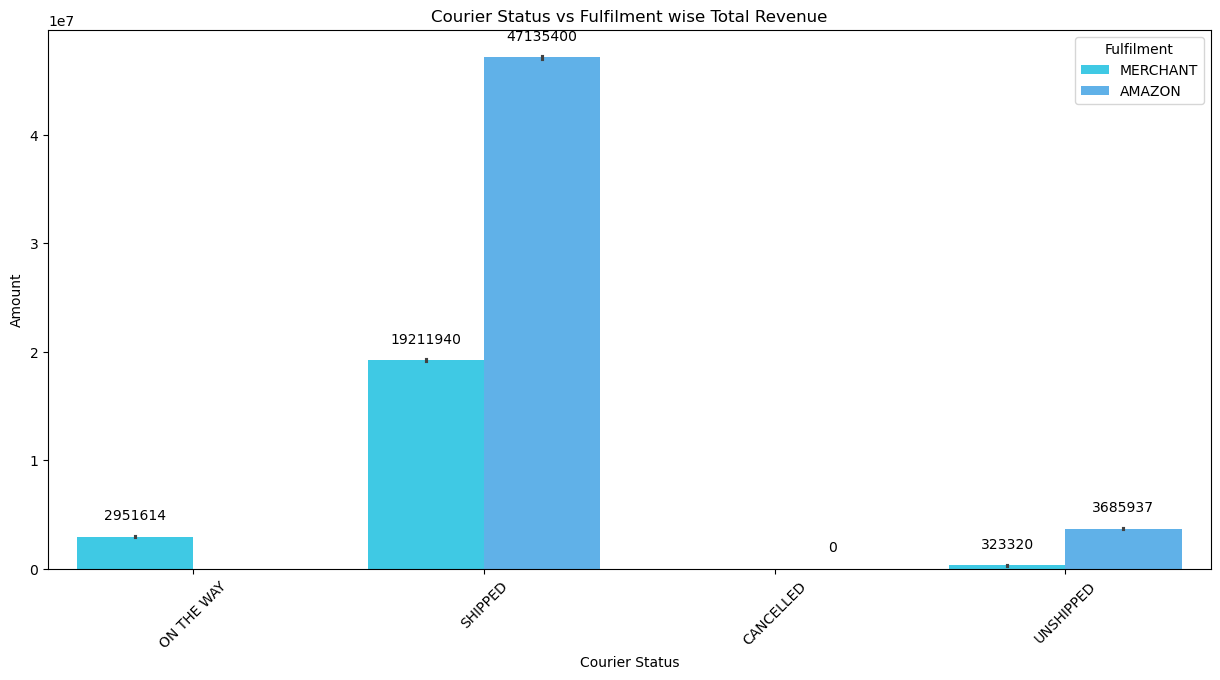

In [77]:
# Courier Status vs Fulfilment wise Revenue
plt.figure(figsize=(15,7))
plt.title('Courier Status vs Fulfilment wise Total Revenue')
ax = sns.barplot(x = 'Courier Status', y = 'Amount', hue = 'Fulfilment', data = final_df, palette=sns.color_palette(random.choice(c)), estimator = 'sum')
for i in ax.containers:
  ax.bar_label(i,  padding=10, fmt = '%.0f')
plt.xticks(rotation = 45)
plt.show()

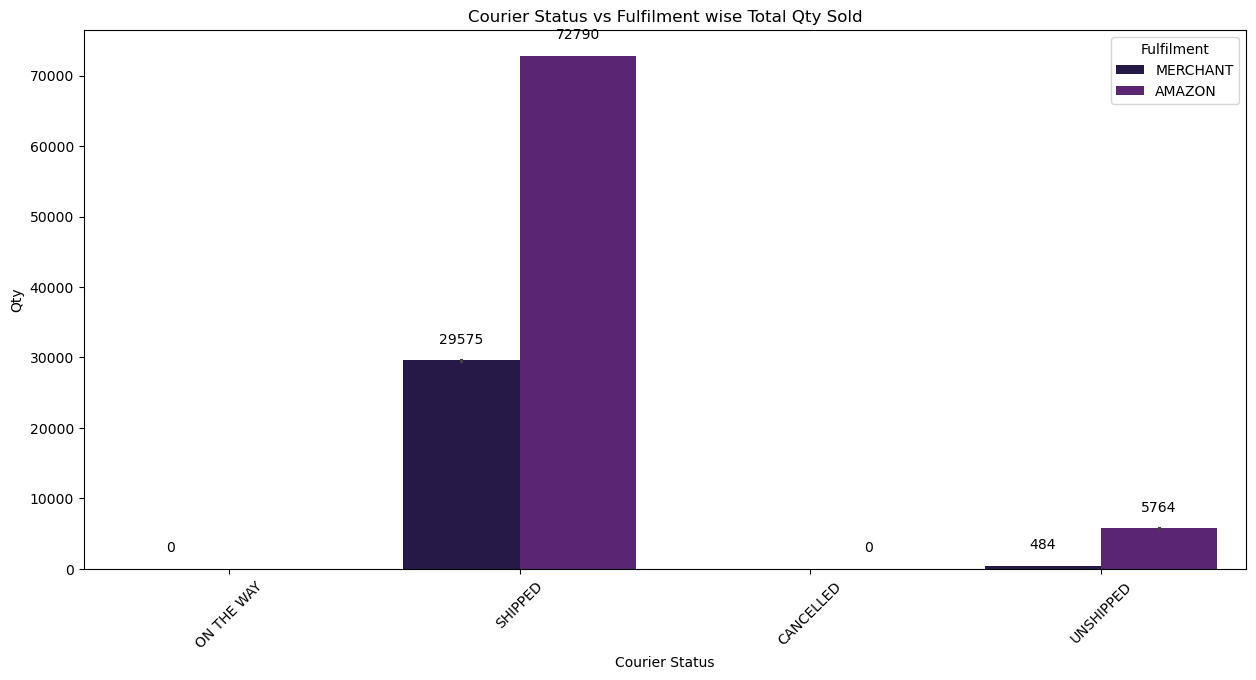

In [78]:
# Courier Status vs Fulfilment wise Qty Sold
plt.figure(figsize=(15,7))
plt.title('Courier Status vs Fulfilment wise Total Qty Sold')
ax = sns.barplot(x = 'Courier Status', y = 'Qty', hue = 'Fulfilment', data = final_df, palette=sns.color_palette(random.choice(c)), estimator = 'sum')
for i in ax.containers:
  ax.bar_label(i,  padding=10, fmt = '%.0f')
plt.xticks(rotation = 45)
plt.show()

### Sales Channel and State-wise Top 10 Revenue

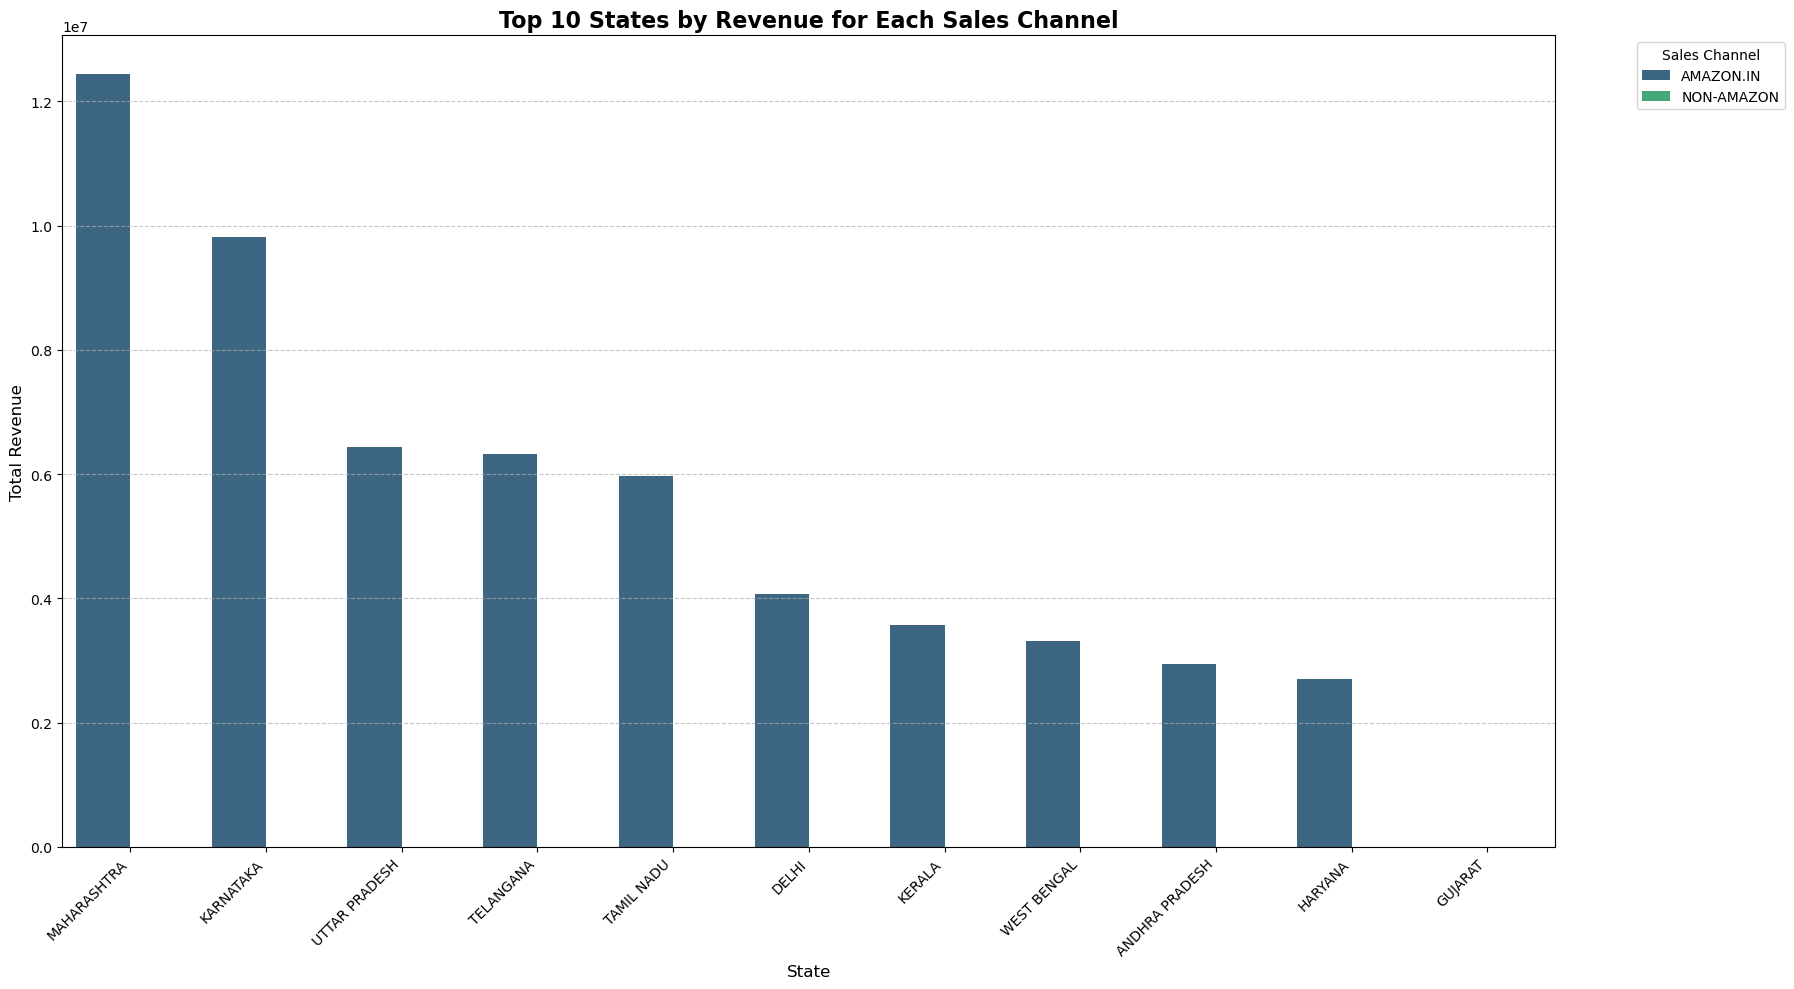

In [79]:
sales_channel_state_revenue = final_df.groupby(['Sales Channel', 'ship-state'])['Amount'].sum().reset_index()

# Get top 10 states for each sales channel
top_10_revenue_by_sales_channel_state = sales_channel_state_revenue.groupby('Sales Channel').apply(lambda x: x.nlargest(10, 'Amount')).reset_index(drop=True)

plt.figure(figsize=(18, 10))
sns.barplot(data=top_10_revenue_by_sales_channel_state,
            x='ship-state',
            y='Amount',
            hue='Sales Channel',
            palette='viridis',
            dodge=True)

plt.title('Top 10 States by Revenue for Each Sales Channel', fontsize=16, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sales Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

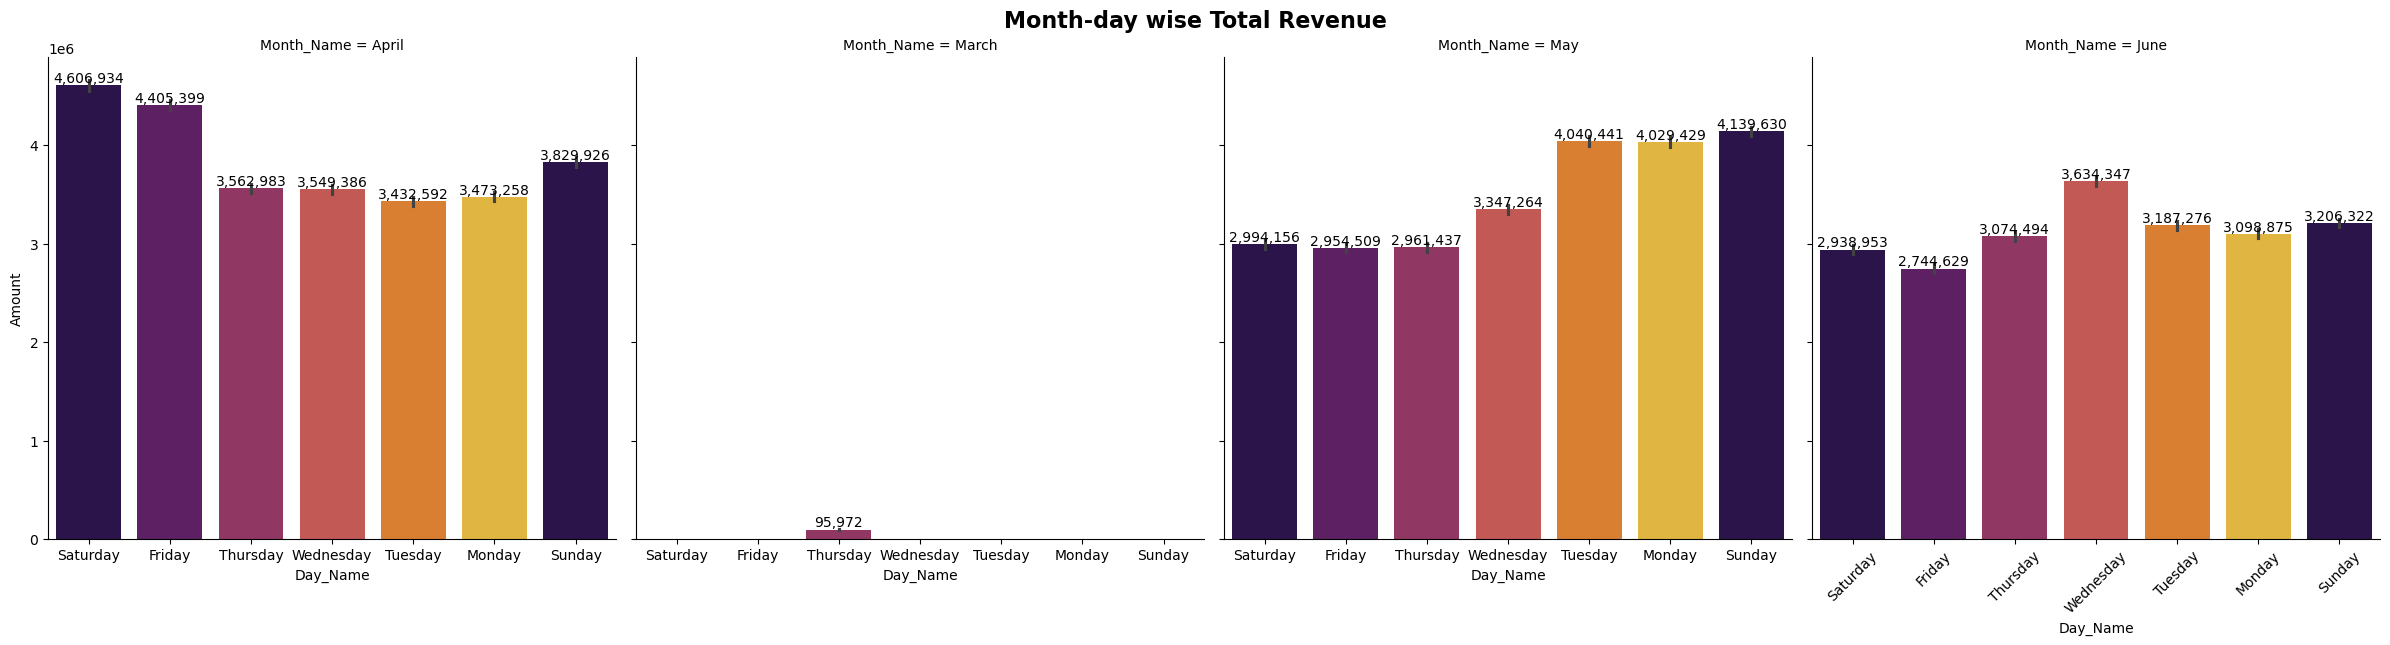

In [80]:
# Month and day wise Total Revenue

g = ax = sns.catplot(x = 'Day_Name',
                 y = 'Amount',
                #  hue = 'Fulfilment',
                 data = final_df,
                 kind = 'bar',
                 col = 'Month_Name',
                 palette=sns.color_palette(random.choice(c)), estimator = 'sum',
                 height=6,
                 aspect=1)
g.fig.suptitle("Month-day wise Total Revenue", fontsize=16, fontweight='bold')
g.fig.subplots_adjust(top=0.9)  # prevents title overlap

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='{:,.0f}'.format)  # 👈 formatting here


plt.xticks(rotation = 45)
plt.show()

In [81]:
final_df.columns

Index(['Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Category', 'Size', 'Courier Status', 'Qty',
       'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code',
       'ship-country', 'B2B', 'fulfilled-by', 'Day_Name', 'Month_Name',
       'Year'],
      dtype='object')

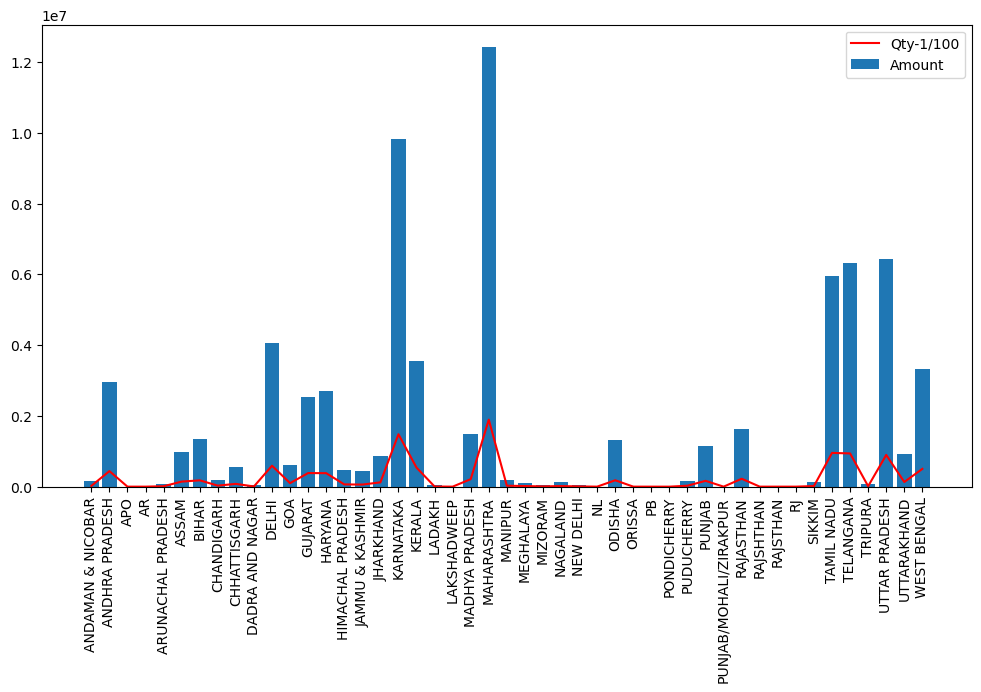

In [82]:
# ship-state vs Amount vs Qty Sold
plt.figure(figsize=(12,6))
# plt.title('Courier Status vs Fulfilment wise Total Qty Sold')
temp_df = final_df.groupby('ship-state')[['Amount','Qty']].sum().reset_index()
plt.plot(temp_df['ship-state'], temp_df['Qty']*100, color = 'r', label = 'Qty-1/100')  # Qty is 1/100 as shown
plt.bar(temp_df['ship-state'], temp_df['Amount'], label = 'Amount')
plt.xticks(rotation = 90)
plt.legend()
plt.show()


# EDA using AI

### Correlation Heatmap: Amount vs. Qty for Each State

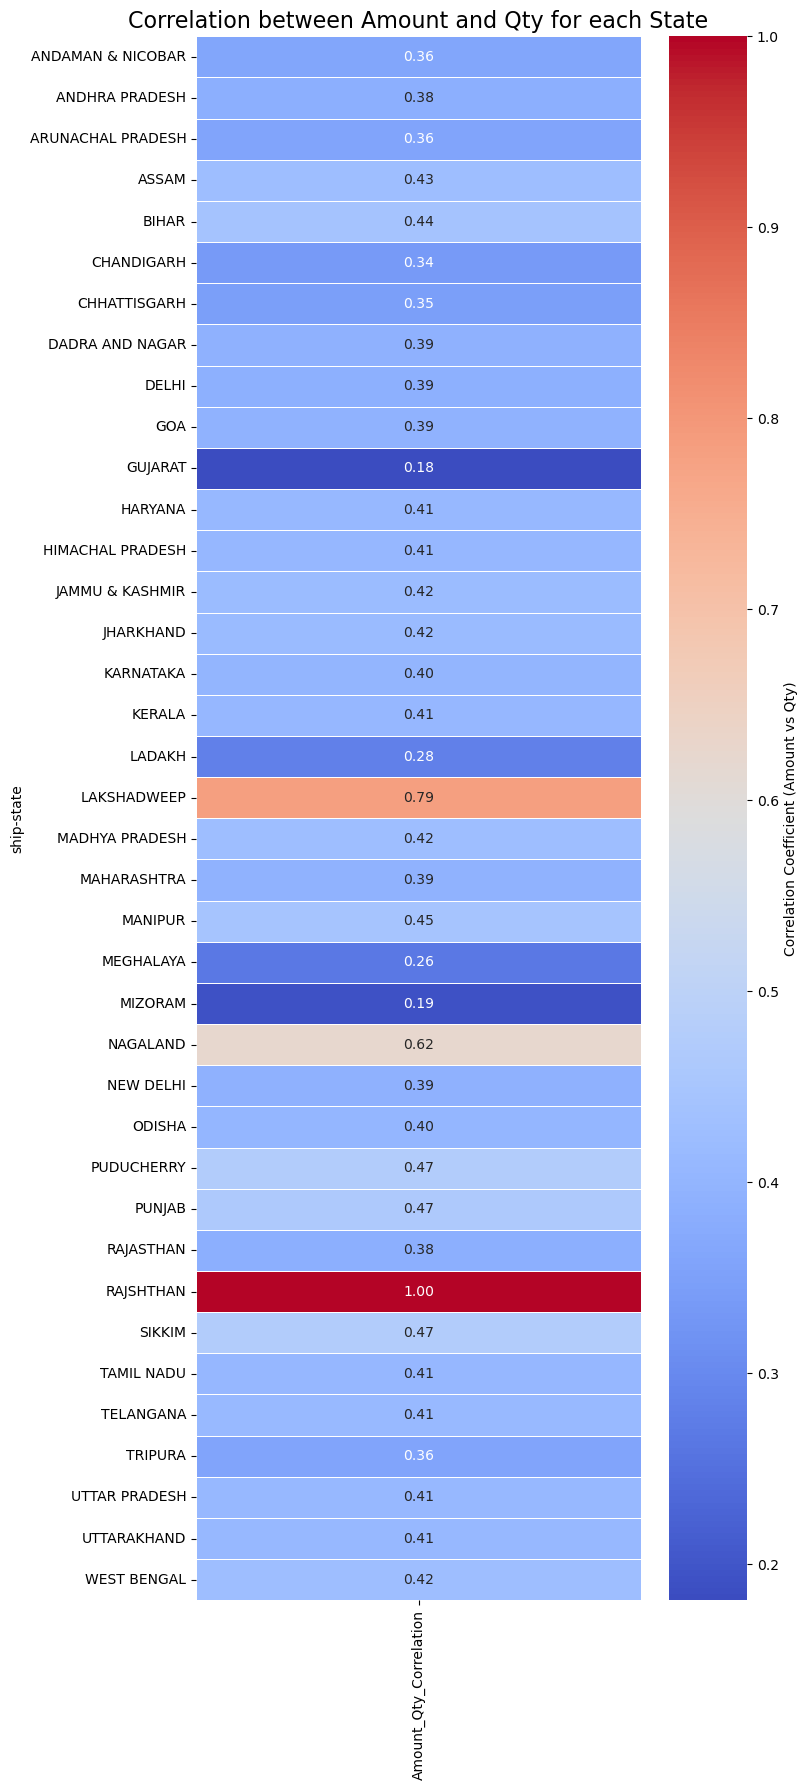

In [83]:
import numpy as np

# Calculate the correlation between 'Amount' and 'Qty' for each state
state_amount_qty_correlation = final_df.groupby('ship-state')[['Amount', 'Qty']].corr().unstack().iloc[:, 1]

# Drop states where correlation couldn't be calculated (e.g., not enough data points or no variance)
state_amount_qty_correlation = state_amount_qty_correlation.dropna()
# Ensure all values are finite (not inf, -inf)
state_amount_qty_correlation = state_amount_qty_correlation[np.isfinite(state_amount_qty_correlation)]

# Convert the Series to a DataFrame for heatmap plotting
# Each state will be a row, and the correlation value will be the single column
correlation_heatmap_df = state_amount_qty_correlation.to_frame(name='Amount_Qty_Correlation')

plt.figure(figsize=(8, 18)) # Adjust figure size for better readability with many states
sns.heatmap(correlation_heatmap_df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5,
            cbar_kws={'label': 'Correlation Coefficient (Amount vs Qty)'})
plt.title('Correlation between Amount and Qty for each State', fontsize=16)
plt.yticks(rotation=0) # Keep state names horizontal
plt.xticks(rotation=90) # Rotate the single column label if it's long
plt.tight_layout()
plt.show()

### Ship-State and Fulfilment wise Quantity Analysis (Clustered Column Chart)

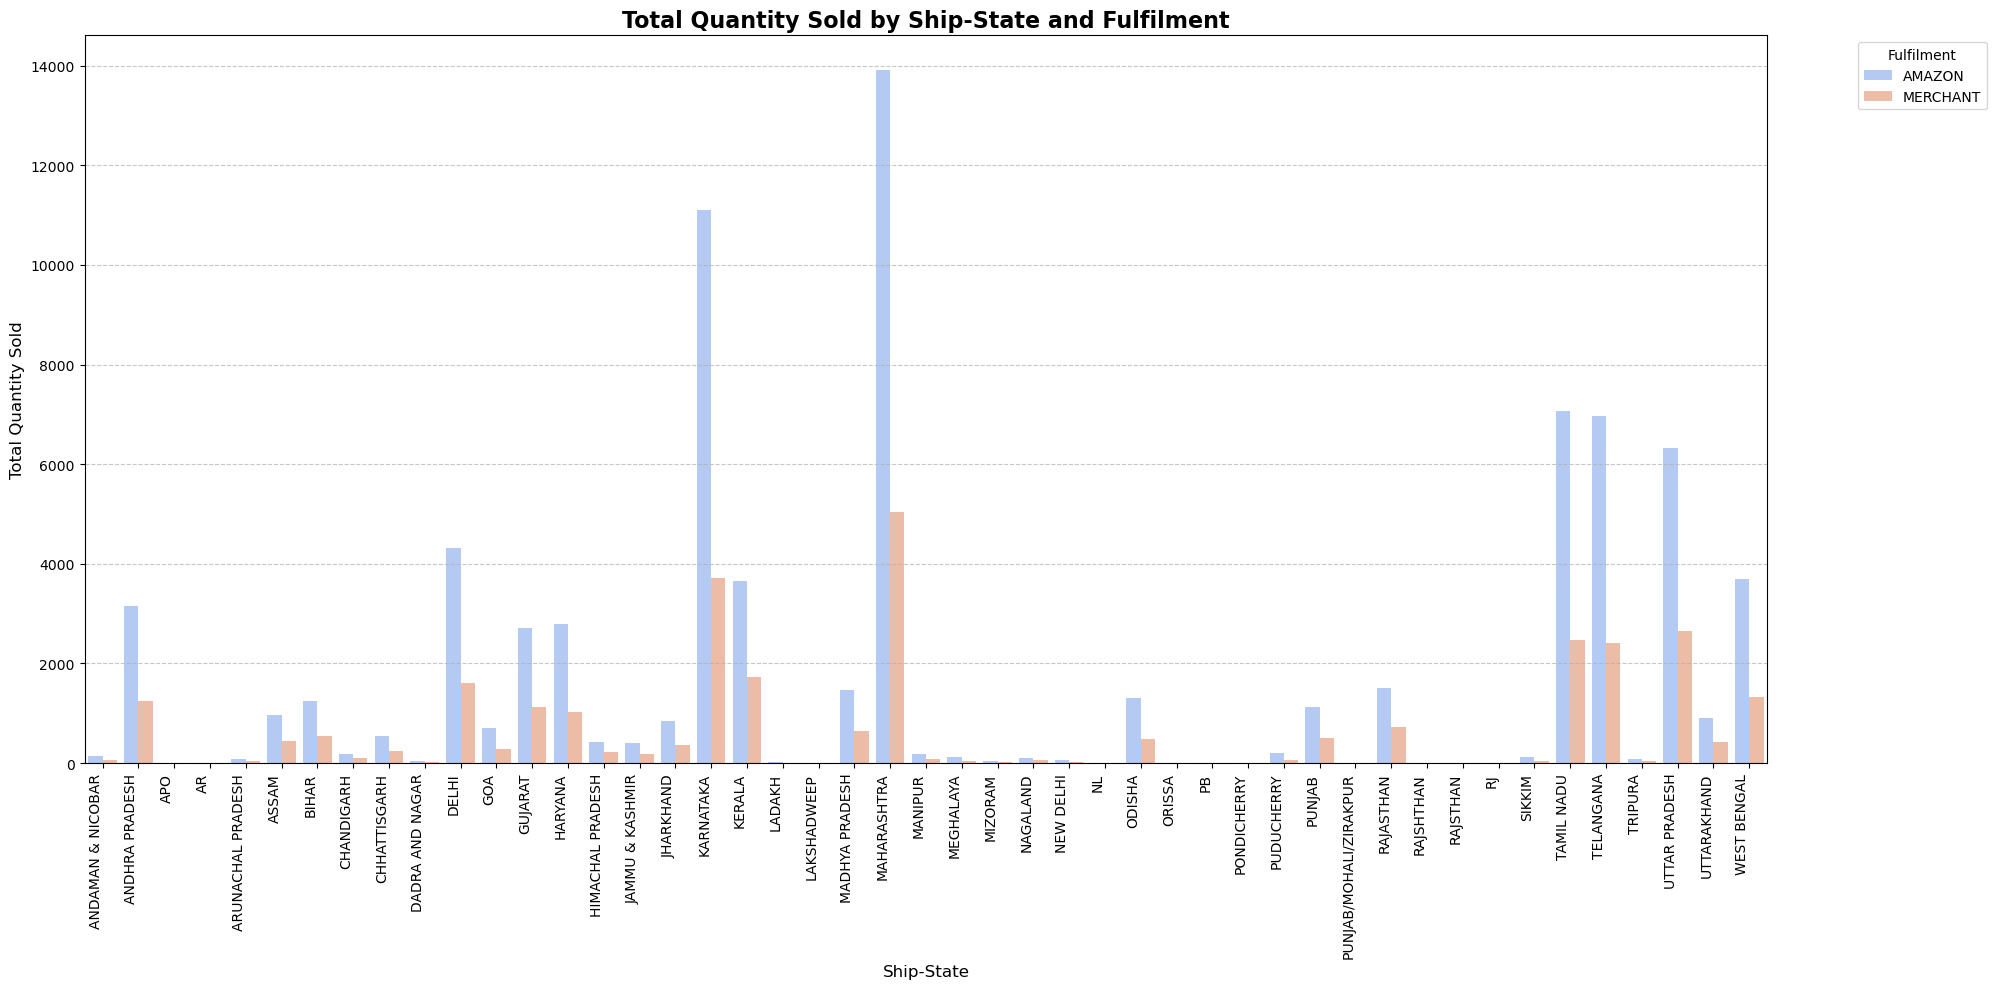

In [84]:
ship_state_fulfilment_qty = final_df.groupby(['ship-state', 'Fulfilment'])['Qty'].sum().reset_index()

plt.figure(figsize=(20, 10)) # Adjust figure size for better readability
sns.barplot(data=ship_state_fulfilment_qty,
            x='ship-state',
            y='Qty',
            hue='Fulfilment',
            palette='coolwarm',
            dodge=True)

plt.title('Total Quantity Sold by Ship-State and Fulfilment', fontsize=16, fontweight='bold')
plt.xlabel('Ship-State', fontsize=12)
plt.ylabel('Total Quantity Sold', fontsize=12)
plt.xticks(rotation=90, ha='right') # Rotate x-axis labels for better visibility
plt.legend(title='Fulfilment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Revenue vs Sales Channel (Stacked Bar Chart)

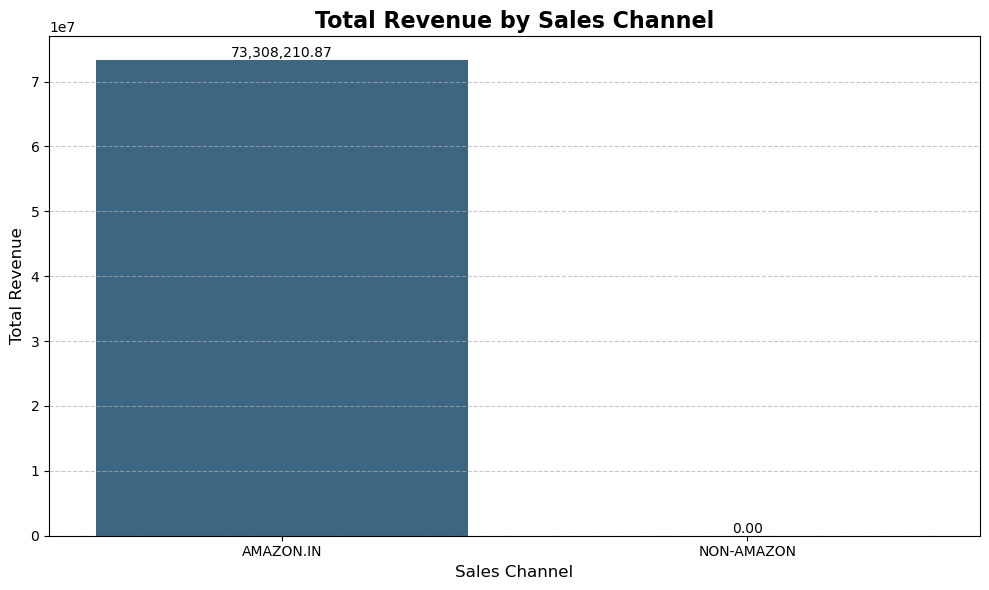

In [85]:
revenue_by_sales_channel = final_df.groupby('Sales Channel')['Amount'].sum().reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Sales Channel', y='Amount', data=revenue_by_sales_channel, palette='viridis')

plt.title('Total Revenue by Sales Channel', fontsize=16, fontweight='bold')
plt.xlabel('Sales Channel', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add labels on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.2f}')

plt.tight_layout()
plt.show()

In [86]:
final_df.sample()

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by,Day_Name,Month_Name,Year
15346,406-8705005-8617111,2022-04-21,SHIPPED - DELIVERED TO BUYER,MERCHANT,AMAZON.IN,STANDARD,SHIRT,M,SHIPPED,1,INR,399.0,NEW DELHI,DELHI,110028.0,IN,False,EASY SHIP,Thursday,April,2022


In [87]:
final_df.columns

Index(['Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Category', 'Size', 'Courier Status', 'Qty',
       'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code',
       'ship-country', 'B2B', 'fulfilled-by', 'Day_Name', 'Month_Name',
       'Year'],
      dtype='object')

In [88]:
# Ship city wise Revenue Amount Analysis


### State-wise Total Revenue Analysis

Given the complexity of generating a city-wise map for thousands of cities without specific geographical coordinates or boundary data, a more feasible and insightful approach is to visualize the total revenue at the **state level**. This provides a clear overview of high-revenue generating regions in India.

In [89]:
import plotly.express as px
import json

# Group by 'ship-state' and sum 'Amount' to get total revenue per state
state_revenue = final_df.groupby('ship-state')['Amount'].sum().reset_index()
state_revenue.columns = ['State', 'Total_Revenue']

# Display the top 10 states by revenue
print('Top 10 States by Total Revenue:')
display(state_revenue.sort_values(by='Total_Revenue', ascending=False).head(10))


Top 10 States by Total Revenue:


,State,Total_Revenue
22,MAHARASHTRA,12440118.52
17,KARNATAKA,9817768.10
44,UTTAR PRADESH,6437670.88
42,TELANGANA,6331438.99
41,TAMIL NADU,5965184.37
10,DELHI,4069730.06
18,KERALA,3564014.15
46,WEST BENGAL,3318224.53
1,ANDHRA PRADESH,2945864.69
13,HARYANA,2702758.71


### Alternative Map Visual: State-wise Revenue as Scatter Points

Given the challenges with finding a consistently reliable GeoJSON file for state boundaries without relying on direct GitHub raw links, an effective alternative is to visualize state-wise revenue using a scatter plot on a map. This method uses approximate central coordinates for each state, with the size and color of the points indicating the total revenue, providing a good visual representation of high-revenue areas.

First, we need approximate latitude and longitude coordinates for each Indian state.

In [90]:
# Approximate centroids for Indian states (simplified for visualization)
state_centroids = {
    'ANDAMAN & NICOBAR': {'lat': 10.7499999, 'lon': 92.500000},
    'ANDHRA PRADESH': {'lat': 15.917987, 'lon': 79.740000},
    'ARUNACHAL PRADESH': {'lat': 28.217999, 'lon': 94.727753},
    'ASSAM': {'lat': 26.200604, 'lon': 92.937574},
    'BIHAR': {'lat': 25.096193, 'lon': 85.313093},
    'CHANDIGARH': {'lat': 30.733315, 'lon': 76.779419},
    'CHHATTISGARH': {'lat': 21.278657, 'lon': 81.866110},
    'DADRA AND NAGAR HAVELI': {'lat': 20.266579, 'lon': 73.016618},
    'DAMAN AND DIU': {'lat': 20.4283, 'lon': 72.8397},
    'DELHI': {'lat': 28.704093, 'lon': 77.102493},
    'GOA': {'lat': 15.299327, 'lon': 74.123996},
    'GUJARAT': {'lat': 22.2587, 'lon': 71.1924},
    'HARYANA': {'lat': 29.058723, 'lon': 76.085601},
    'HIMACHAL PRADESH': {'lat': 31.104829, 'lon': 77.173403},
    'JAMMU & KASHMIR': {'lat': 33.778179, 'lon': 76.576150},
    'JHARKHAND': {'lat': 23.61017, 'lon': 85.2799},
    'KARNATAKA': {'lat': 14.900300, 'lon': 76.000000},
    'KERALA': {'lat': 10.850516, 'lon': 76.271083},
    'LADAKH': {'lat': 34.1526, 'lon': 77.5771},
    'LAKSHADWEEP': {'lat': 10.5667, 'lon': 72.6333},
    'MADHYA PRADESH': {'lat': 22.9734, 'lon': 78.6569},
    'MAHARASHTRA': {'lat': 19.751480, 'lon': 75.713888},
    'MANIPUR': {'lat': 24.6637, 'lon': 93.9068},
    'MEGHALAYA': {'lat': 25.4670, 'lon': 91.3662},
    'MIZORAM': {'lat': 23.1645, 'lon': 92.9376},
    'NAGALAND': {'lat': 26.1584, 'lon': 94.5624},
    'ODISHA': {'lat': 20.9517, 'lon': 85.0985},
    'PUDUCHERRY': {'lat': 11.9416, 'lon': 79.8083},
    'PUNJAB': {'lat': 31.1471, 'lon': 75.3412},
    'RAJASTHAN': {'lat': 27.0238, 'lon': 74.2179},
    'SIKKIM': {'lat': 27.5330, 'lon': 88.5122},
    'TAMIL NADU': {'lat': 11.1271, 'lon': 78.6569},
    'TELANGANA': {'lat': 18.1124, 'lon': 79.0193},
    'TRIPURA': {'lat': 23.9408, 'lon': 91.9882},
    'UTTAR PRADESH': {'lat': 26.8467, 'lon': 80.9462},
    'UTTARAKHAND': {'lat': 30.0668, 'lon': 79.0193},
    'WEST BENGAL': {'lat': 22.9868, 'lon': 87.8550},
    'APO': {'lat': 28.7041, 'lon': 77.1025}, # Assuming same as Delhi if no specific location
    'AR': {'lat': 28.2180, 'lon': 94.7278} # Assuming same as Arunachal Pradesh if no specific location
}

# Convert state_centroids to a DataFrame
state_coords_df = pd.DataFrame.from_dict(state_centroids, orient='index')
state_coords_df = state_coords_df.reset_index().rename(columns={'index': 'State'})

# Merge state_revenue with state_coordinates
state_revenue_geo = pd.merge(state_revenue, state_coords_df, on='State', how='left')

# Display the merged DataFrame
print("State Revenue with Geocoordinates (Top 10):")
display(state_revenue_geo.sort_values(by='Total_Revenue', ascending=False).head(10))


State Revenue with Geocoordinates (Top 10):


,State,Total_Revenue,lat,lon
22,MAHARASHTRA,12440118.52,19.751480,75.713888
17,KARNATAKA,9817768.10,14.900300,76.000000
44,UTTAR PRADESH,6437670.88,26.846700,80.946200
42,TELANGANA,6331438.99,18.112400,79.019300
41,TAMIL NADU,5965184.37,11.127100,78.656900
10,DELHI,4069730.06,28.704093,77.102493
18,KERALA,3564014.15,10.850516,76.271083
46,WEST BENGAL,3318224.53,22.986800,87.855000
1,ANDHRA PRADESH,2945864.69,15.917987,79.740000
13,HARYANA,2702758.71,29.058723,76.085601


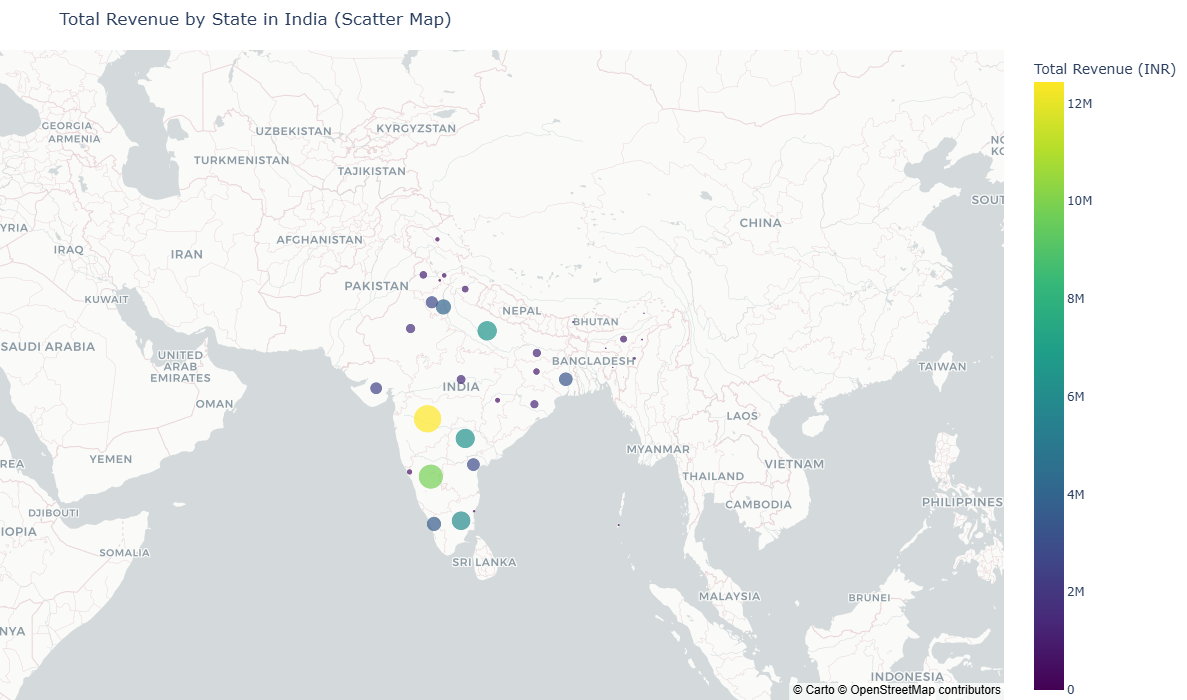

In [91]:
import plotly.graph_objects as go

# Create the scatter mapbox plot
fig = px.scatter_mapbox(
    state_revenue_geo,
    lat="lat",
    lon="lon",
    size="Total_Revenue", # Size of markers based on revenue
    color="Total_Revenue", # Color of markers based on revenue
    color_continuous_scale=px.colors.sequential.Viridis,
    hover_name="State",
    hover_data={'Total_Revenue': ':,.2f'},
    zoom=3, # Adjust zoom level as needed
    height=700,
    title='Total Revenue by State in India (Scatter Map)',
    mapbox_style="carto-positron" # A light map style
)

fig.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0},
    coloraxis_colorbar_title_text='Total Revenue (INR)'
)

fig.show()


### Explanation of the Scatter Map:

*   This map visualizes each Indian state as a circle.
*   The **size** of each circle is proportional to the `Total_Revenue` generated from that state.
*   The **color** of each circle also represents the `Total_Revenue`, with darker shades (as per the Viridis scale) indicating higher revenue.
*   Hovering over a circle will show the state name and its exact `Total_Revenue`.

This approach effectively highlights the regions with the highest sales performance, similar to a choropleth, but without the dependency on external GeoJSON boundary files.

### Explanation of the State-wise Map:

*   The map above uses a choropleth visualization to show the total revenue generated from each Indian state.
*   Darker shades indicate higher revenue, providing an immediate visual understanding of key sales regions.
*   Hovering over a state will display its name and the exact total revenue.

**Note on City-wise Mapping:**

While this map provides state-level insights, a city-wise map would require geographical coordinates (latitude and longitude) for each of the approximately **7,291 unique cities** in the dataset, or a highly detailed GeoJSON file containing the boundaries of these cities. Retrieving such precise data for all cities and then plotting them effectively can be a complex and resource-intensive task. If city-level visualization is critically needed, a separate process to acquire and integrate this geographical data would be necessary, potentially using external geocoding services (which may have usage limits) or specialized geographical data sources.

In [92]:
final_df.columns

Index(['Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Category', 'Size', 'Courier Status', 'Qty',
       'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code',
       'ship-country', 'B2B', 'fulfilled-by', 'Day_Name', 'Month_Name',
       'Year'],
      dtype='object')

# Amazon Sales Data Analysis: Project Summary, Insights, Conclusions, and Recommendations

## 📊 Project Summary

This project involved a comprehensive Exploratory Data Analysis (EDA) of an Amazon sales dataset. The primary goal was to uncover key trends, patterns, and insights related to sales performance, customer behavior, and logistical efficiency. The analysis covered data cleaning, univariate, bivariate, and multivariate analysis, culminating in visualizations to present findings on revenue, quantity sold, and fulfillment methods across different categories, states, and time periods.

## 📈 Key Insights

Here are the crucial findings from the analysis, supported by relevant Key Performance Indicators (KPIs), facts, and figures:

*   **Data Quality & Cleaning:**
    *   The initial dataset contained `128,976` records.
    *   After identifying and dropping `6.78%` duplicate orders (`8,747` duplicate 'Order ID's) and handling missing values, `120,201` unique and clean orders remained for analysis. This ensures the reliability of our findings.

*   **Order Volume Trends:**
    *   **Monthly Performance:** `April 2022` recorded the highest order count with `45,698` orders, indicating a peak sales period.
    *   **Daily Performance:** `Sundays` consistently showed the highest order activity, with `18,205` orders, suggesting a strong weekend shopping trend.

*   **Top Selling Products & Categories:**
    *   The `T-SHIRT` category emerged as the top-selling product, accounting for `47,135` units sold, highlighting its popularity among customers.

*   **Fulfillment Channel Effectiveness:**
    *   `Amazon-fulfilled` orders generated significantly more revenue, totaling approximately `73.31 Million INR`.
    *   In contrast, `Merchant-fulfilled` orders contributed around `30.09 Million INR` in revenue. This indicates that Amazon's own fulfillment network drives a substantial portion of the sales.

*   **Geographical Performance:**
    *   **Top States by Revenue:** `MAHARASHTRA` and `KARNATAKA` were identified as the top-performing states in terms of total revenue, closely followed by Uttar Pradesh and Telangana. Maharashtra alone generated over `12.44 Million INR`.
    *   These states represent key markets for Amazon and warrant focused attention for growth strategies.

## 🎯 Conclusions

Based on the insights derived from the Amazon sales data:

*   The sales data exhibited clear seasonality and daily patterns, with April and Sundays being prime periods.
*   Certain product categories, particularly "T-SHIRT," have a strong market presence and customer demand.
*   Amazon's fulfillment infrastructure is a major revenue driver, significantly outperforming merchant-fulfilled options.
*   Sales are highly concentrated in a few key states, presenting both opportunities for deeper penetration and a potential risk of over-reliance on these regions.

## 💡 Recommendations

To leverage these findings and improve overall sales performance:

*   **Optimize Marketing & Promotions:**
    *   Focus marketing campaigns and promotional offers around `April` and `Sundays` to capitalize on historically high sales periods.
    *   Consider special weekend deals or flash sales to further boost Sunday sales.

*   **Expand Top-Performing Categories:**
    *   Invest further in the `T-SHIRT` category by expanding product variety, introducing new designs, and optimizing inventory management.
    *   Analyze other top-selling categories for similar growth opportunities.

*   **Enhance Merchant-Fulfilled Support/Incentives:**
    *   Investigate reasons for the lower revenue contribution from `Merchant-fulfilled` orders.
    *   Provide enhanced support, training, or incentives to merchant partners to improve their sales performance and fulfillment efficiency. This could include better logistics integration or marketing support.

*   **Target Growth in Key States & Explore New Markets:**
    *   Deepen market penetration in `Maharashtra`, `Karnataka`, `Uttar Pradesh`, and `Telangana` through localized strategies.
    *   Simultaneously, identify and develop strategies for states with lower sales figures but high growth potential, avoiding over-saturation in existing top markets.
    *   For states with lower sales and merchant-fulfilled predominance, tailor strategies to improve merchant performance or expand Amazon's direct fulfillment options.

## 🔍 SWOT Analysis of Amazon Sales Performance

This SWOT (Strengths, Weaknesses, Opportunities, Threats) analysis summarizes the internal and external factors affecting Amazon's sales performance based on the provided dataset.

### 💪 Strengths

*   **Strong Fulfillment Network:** `Amazon-fulfilled` orders generated significantly higher revenue (approximately `73.31 Million INR`) compared to `Merchant-fulfilled` orders (approximately `30.09 Million INR`). This indicates a robust and efficient internal logistics system.
*   **High Demand for Key Products:** The `T-SHIRT` category is a top performer, with `47,135` units sold, showcasing a strong product market fit and consumer interest.
*   **Dominant Market Presence in Key Regions:** States like `MAHARASHTRA` (`12.44 Million INR` in revenue) and `KARNATAKA` (`9.82 Million INR` in revenue) are strong revenue generators, indicating established customer bases and effective distribution in these areas.
*   **Weekend Sales Spike:** `Sundays` consistently record the highest order counts (`18,205` orders), suggesting a positive consumer habit for weekend shopping.

### 📉 Weaknesses

*   **Underperforming Merchant Fulfillment:** `Merchant-fulfilled` orders contribute less than half of the revenue compared to Amazon's own fulfillment, potentially indicating inefficiencies, lack of support, or lower trust in merchant partners.
*   **Dependence on Specific States:** Sales are highly concentrated in a few top states. While a strength, over-reliance can be a weakness if these markets face economic downturns or increased competition.
*   **Seasonality and Fluctuating Sales:** While `April 2022` had the highest order count (`45,698` orders), other months might have lower performance, indicating potential seasonal weaknesses if not managed proactively.
*   **Geographical Gaps:** Some states or regions might be underserviced or have lower penetration, representing untapped potential or inefficient market reach. For instance, 'APO' has `0.00 INR` revenue, indicating negligible or non-existent sales.

### 🚀 Opportunities

*   **Optimize Merchant-Fulfilled Program:** Implement strategies to improve the performance of `Merchant-fulfilled` orders through better integration, training, and incentives, potentially converting a weakness into a growth opportunity.
*   **Expand Top Categories:** Further invest in and diversify product offerings within the `T-SHIRT` category and other high-performing product types. This could include new designs, sizes, and collaborations.
*   **Targeted Marketing:** Capitalize on peak periods like `April` and `Sundays` with targeted marketing campaigns and promotions to maximize sales during these high-demand times.
*   **Market Expansion:** Explore strategies to increase sales in lower-performing states or cities, potentially through localized marketing, improved logistics, or tailored product selections.

### 🚨 Threats

*   **Competition:** Intense competition from other e-commerce platforms and local retailers constantly threatens market share and pricing power.
*   **Logistical Challenges:** Potential disruptions in supply chains or last-mile delivery can impact customer satisfaction and fulfillment efficiency, especially in remote or less-developed regions.
*   **Economic Downturns:** Broader economic factors affecting consumer spending can negatively impact overall sales volume and revenue, particularly for non-essential items.
*   **Customer Preferences Shift:** Rapid changes in fashion trends or consumer buying habits could impact the demand for currently popular categories like `T-SHIRT` if the inventory is not agile enough to adapt.

# Designed and Devloped by: Ankit